In [1]:
# Accessing Github data files from colab
from google.colab import userdata
token = userdata.get('github')
!git clone -b rm/data_cleaning https://{token}@github.com/Marconi-Lab/Solar_irradiation.git

Cloning into 'Solar_irradiation'...
remote: Enumerating objects: 19506, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 19506 (delta 11), reused 7 (delta 7), pack-reused 19463 (from 4)
Receiving objects: 100% (19506/19506), 280.49 MiB | 10.07 MiB/s, done.
Resolving deltas: 100% (2962/2962), done.
Updating files: 100% (102/102), done.


In [2]:
import pandas as pd
data = pd.read_csv('/content/Solar_irradiation/jupyter_notebooks/Data/irradiation_estimates/all_locations_train_data.csv')
data.head()

,datetime,ghi,location,T2M,ALLSKY_SFC_SW_DWN,RH2M,WS2M,T2MDEW,T2M_MAX,T2M_MIN,...,ghi_clear_cams,bhi_clear_cams,dhi_clear_cams,dni_clear_cams,ghi_cams,bhi_cams,dhi_cams,dni_cams,latitude,longitude
0,2019-05-28,4.5895,kenya_location3,20.24,5.85,75.35,1.89,15.40,25.60,15.51,...,7028.7080,5860.6655,1168.0425,8644.8447,5709.2358,3214.8335,2494.4021,5085.8491,-0.469974,35.181874
1,2019-05-29,6.4772,kenya_location3,19.79,5.87,79.56,1.69,15.93,24.54,16.12,...,6983.8623,5600.8086,1383.0536,8156.0479,5820.1196,3751.4502,2068.6694,5344.3003,-0.469974,35.181874
2,2019-05-30,4.0908,kenya_location3,20.29,5.81,77.34,2.23,15.90,25.47,15.59,...,7108.9385,6082.7812,1026.1572,9049.8369,4649.3599,2996.5430,1652.8168,4057.3140,-0.469974,35.181874
3,2019-05-31,5.9658,kenya_location3,20.34,5.61,79.87,1.31,16.53,24.50,17.26,...,6939.8794,5645.0093,1294.8701,8293.1592,5853.1040,4095.9358,1757.1682,5564.8662,-0.469974,35.181874
4,2019-06-01,3.7295,kenya_location3,18.56,4.12,87.30,1.57,16.37,21.07,16.83,...,6752.1333,5060.3564,1691.7769,7281.5659,3706.7803,1383.7960,2322.9841,1843.5648,-0.469974,35.181874


In [3]:
#@title Process Data
import pandas as pd
import numpy as np

def preprocess_data(df):
    """
    Preprocesses the input DataFrame by performing the following steps:
    1. Drops the 'Unnamed: 0' column.
    2. Sets the 'datetime' column as the index.
    3. Converts CAMS data to kW.
    4. Renames specific columns.
    5. Adds 'Month', 'dayofyear_sin', and 'dayofyear_cos' columns.

    Args:
        df (pd.DataFrame): The input DataFrame.

    Returns:
        pd.DataFrame: The preprocessed DataFrame.
    """
    df.index = pd.to_datetime(df['datetime'])

    # Convert CAMS data to kW
    cams_cols = ['ghi_extr_cams', 'ghi_clear_cams', 'bhi_clear_cams',
                 'dhi_clear_cams', 'dni_clear_cams', 'ghi_cams',
                 'bhi_cams', 'dhi_cams', 'dni_cams']
    for col in cams_cols:
        df[col] = df[col] / 1000

    # Rename columns
    def rename_cols(df):
        return df.rename(columns={
            'ALLSKY_SFC_SW_DWN': 'ghi_nasa',
            'ALLSKY_SFC_SW_DIFF': 'bhi_nasa',
            'ALLSKY_SFC_SW_DNI': 'dni_nasa',
            'CLRSKY_SFC_LW_DWN': 'clear_ghi_nasa',
            'DoY': 'dayofyear',
        })

    df = rename_cols(df)

    # Add Month and dayofyear features
    df['Month'] = df.index.month
    df['dayofyear_sin'] = df['dayofyear'].apply(lambda x: np.sin(2 * np.pi * x / 365))
    df['dayofyear_cos'] = df['dayofyear'].apply(lambda x: np.cos(2 * np.pi * x / 365))

    df['kt_cams'] = df['ghi_cams'] / df['ghi_clear_cams']

    return df

In [4]:
df = preprocess_data(data.copy())
df_copy = df.copy()
df.head()

,datetime,ghi,location,T2M,ghi_nasa,RH2M,WS2M,T2MDEW,T2M_MAX,T2M_MIN,...,ghi_cams,bhi_cams,dhi_cams,dni_cams,latitude,longitude,Month,dayofyear_sin,dayofyear_cos,kt_cams
datetime,,,,,,,,,,,,,,,,,,,,,
2019-05-28,2019-05-28,4.5895,kenya_location3,20.24,5.85,75.35,1.89,15.40,25.60,15.51,...,5.709236,3.214834,2.494402,5.085849,-0.469974,35.181874,5,0.559589,-0.828770,0.812274
2019-05-29,2019-05-29,6.4772,kenya_location3,19.79,5.87,79.56,1.69,15.93,24.54,16.12,...,5.820120,3.751450,2.068669,5.344300,-0.469974,35.181874,5,0.545240,-0.838280,0.833367
2019-05-30,2019-05-30,4.0908,kenya_location3,20.29,5.81,77.34,2.23,15.90,25.47,15.59,...,4.649360,2.996543,1.652817,4.057314,-0.469974,35.181874,5,0.530730,-0.847541,0.654016
2019-05-31,2019-05-31,5.9658,kenya_location3,20.34,5.61,79.87,1.31,16.53,24.50,17.26,...,5.853104,4.095936,1.757168,5.564866,-0.469974,35.181874,5,0.516062,-0.856551,0.843401
2019-06-01,2019-06-01,3.7295,kenya_location3,18.56,4.12,87.30,1.57,16.37,21.07,16.83,...,3.706780,1.383796,2.322984,1.843565,-0.469974,35.181874,6,0.501242,-0.865307,0.548979


In [5]:
soroti = df[df['location'] == 'soroti'].copy()
soroti.head()

,datetime,ghi,location,T2M,ghi_nasa,RH2M,WS2M,T2MDEW,T2M_MAX,T2M_MIN,...,ghi_cams,bhi_cams,dhi_cams,dni_cams,latitude,longitude,Month,dayofyear_sin,dayofyear_cos,kt_cams
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-01,2020-02-01,2.55,soroti,21.09,3.85,79.84,1.47,17.25,24.69,18.62,...,2.421314,0.309806,2.111508,0.598787,1.7153,33.6186,2,0.523416,0.852078,0.324389
2020-02-02,2020-02-02,6.10,soroti,22.60,6.09,68.88,1.12,16.36,26.61,17.73,...,6.273288,3.615301,2.657987,4.698738,1.7153,33.6186,2,0.538005,0.842942,0.857126
2020-02-03,2020-02-03,4.69,soroti,23.45,4.52,73.88,1.26,18.32,27.64,18.56,...,4.786023,2.882874,1.903148,3.573701,1.7153,33.6186,2,0.552435,0.833556,0.665693
2020-02-04,2020-02-04,6.69,soroti,23.67,6.58,75.86,1.02,18.77,28.71,19.00,...,7.247579,5.693938,1.553641,7.733093,1.7153,33.6186,2,0.566702,0.823923,0.970526
2020-02-05,2020-02-05,6.03,soroti,23.87,6.27,75.49,1.06,18.89,28.40,19.90,...,7.097784,5.193476,1.904309,7.177337,1.7153,33.6186,2,0.580800,0.814046,0.954960


In [6]:
#@title Features
feature_cols = [
    'T2M',               # Daily Avg Temp
    'RH2M',              # Daily Avg RH
    'AOD_55_ADJ',        # Daily Avg AOD
    'CLOUD_AMT',         # Daily Avg Cloud
    'PW',                # Daily Avg Water Vapor
    'dayofyear_sin',     # Seasonality (Engineered)
    'dayofyear_cos',     # Seasonality (Engineered)
    'PRECTOTCORR',       # Daily Precip Total
    'T2M_RANGE',         # Daily Temp Range
    'Z0M',               # Surface Roughness
    'V2M',               # Northward Wind at 2M
    'AIRMASS',           # Airmass
    'DISPH',             # Zero Plane Displacement Height
    'altitude',          # Altitude
    'EVPTRNS',           # Evapotranspiration Energy Flux
    'PBLTOP',            # Planetary Boundary Layer Top Pressure
    'TO3',               # Total Column Ozone
    'RHOA',              # Surface Air Density
    'SRF_ALB_ADJ',       # Surface Albedo Adjusted
    'EVLAND',            # Evaporation Land
    'GWETTOP',           # Surface Soil Wetness
    'ALLSKY_KT',         # All Sky Insolation Clearness Index
    'ghi_clear_cams',    # Clearsky ghi CAMSRAD
    'bhi_clear_cams',    # Clearcky bhi CAMSRAD
    'dhi_clear_cams',
    'dni_clear_cams',
    'ghi_cams',
    'bhi_cams',
    'dhi_cams',
    'dni_cams',
    'Month',
    'kt_cams',
    'ghi_nasa',
    'bhi_nasa',
    'dni_nasa',
    'clear_ghi_nasa'
]

In [7]:
#@title parameter plot
import matplotlib.pyplot as plt
def plot_ghi_and_parameters(data, ghi_col='ghi', ghi_cams_col='ghi_cams',ghi_nasa_col='ALLSKY_SFC_SW_DWN', parameter='CLRSKY_DAYS', size=100):
    """Plots GHI, GHI CAMS, and CLRSKY_DAYS over time.

    Args:
        data: pandas DataFrame containing the data.
        ghi_col: Name of the GHI column in the DataFrame.
        ghi_cams_col: Name of the GHI CAMS column in the DataFrame.
        ghi_nasa_col: Name of the GHI NASA column in the DataFrame.
        paramters_col: Name of the parameters column in the DataFrame.
        size: Number of points to plot.
    """
    fig, axs = plt.subplots(2, 1, figsize=(14, 10))

    # ghi and ghi_cams plot
    axs[0].plot(data.index[:size], data[ghi_col].iloc[:size], label='GHI')
    axs[0].plot(data.index[:size], data[ghi_cams_col].iloc[:size], label='GHI CAMS')
    axs[0].plot(data.index[:size], data[ghi_nasa_col].iloc[:size], label='GHI NASA')
    axs[0].set_xlabel('Date')
    axs[0].set_ylabel('GHI')
    axs[0].legend()

    axs[1].plot(data.index[:size], data[parameter].iloc[:size], label=parameter)
    axs[1].set_xlabel('Date')
    axs[1].set_ylabel(parameter)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

In [8]:
# create a plot for every feature in the feature_cols
for feature in feature_cols:
    plot_ghi_and_parameters(soroti, ghi_col='ghi', ghi_cams_col='ghi_cams', ghi_nasa_col='ghi_nasa', parameter=feature, size=100)

Output hidden; open in https://colab.research.google.com to view.

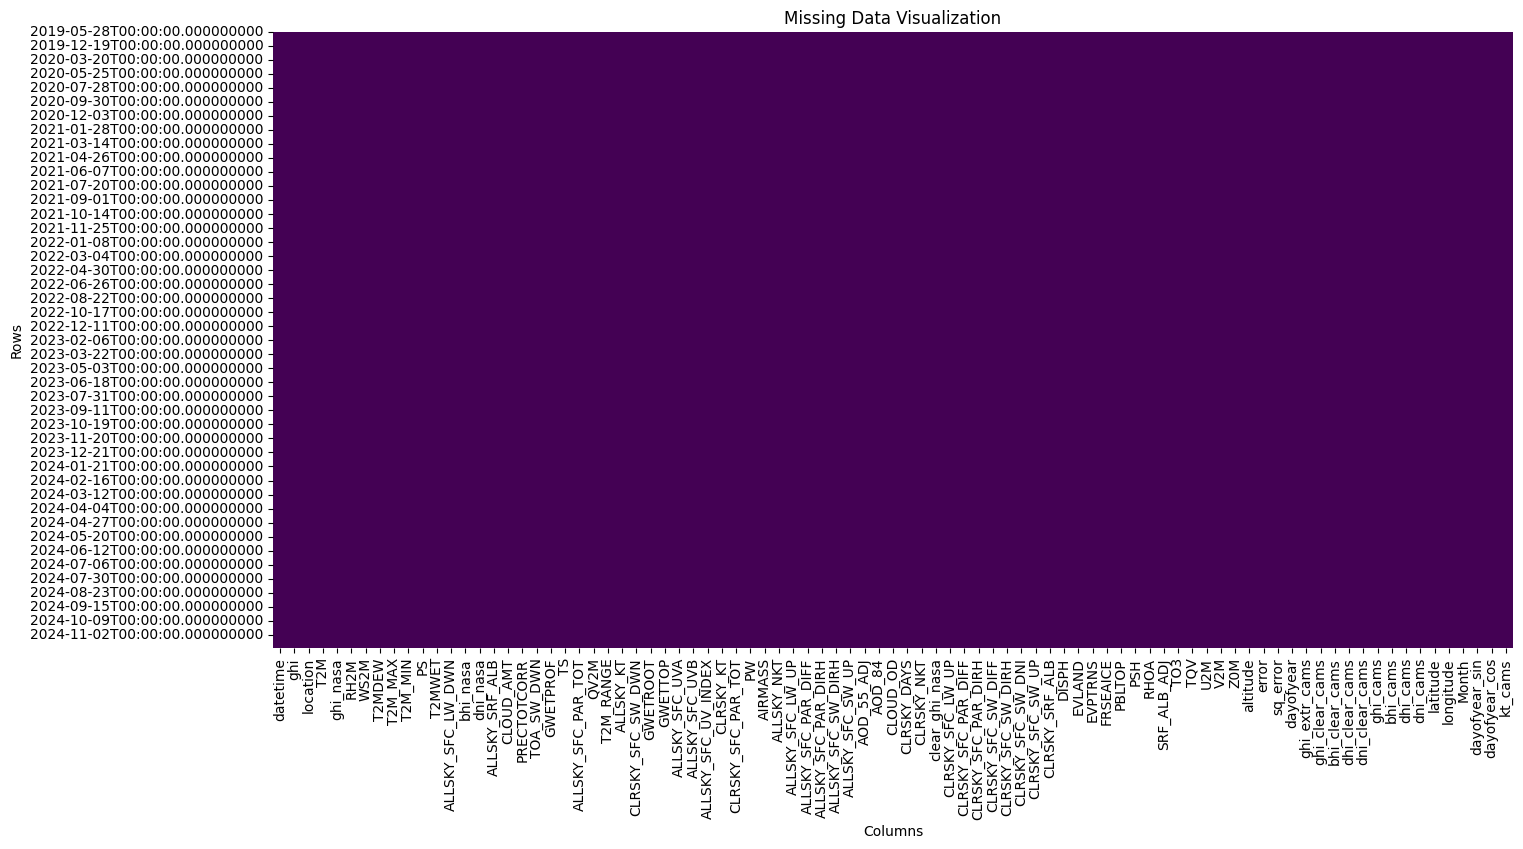

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(16, 8))  # Adjust figure size as needed

# Create the heatmap using seaborn
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

# Customize the plot
plt.title('Missing Data Visualization')
plt.xlabel('Columns')
plt.ylabel('Rows')

plt.show()

In [10]:
#@title imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.interpolate import interp1d
from scipy.stats import ks_2samp
from sklearn.svm import SVR
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import re


In [11]:
#@title Pipeline

def calculate_metrics(y_true, y_pred, model_name="Model", verbose=True, latex=True):
    """
    Calculates standard regression metrics including the Kolmogorov-Smirnov statistic (KSI).

    Args:
        y_true (array-like): Ground truth values.
        y_pred (array-like): Predicted values.
        model_name (str): Name of the model for printing.
        verbose (bool): Whether to print the metrics.
        latex (bool): Whether to print the metrics in LaTeX table format.

    Returns:
        dict: Dictionary containing the calculated metrics: RMSE, MAE, R2, MBE, KSI.
    """
    print(f"--- {model_name} Performance ---")
    # Ensure inputs are numpy arrays for consistency
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mbe = np.mean(y_pred - y_true)
    ks_stat, _ = ks_2samp(y_true, y_pred)

    if verbose:
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")
        print(f"R²:   {r2:.4f}")
        print(f"MBE:  {mbe:.4f}")
        print(f"KSI:  {ks_stat:.4f}") # Print KSI
        print("-" * (len(model_name) + 20))

    if latex:
        print('Latex version')
        # Add KSI to the latex output
        print(f'{rmse:.4f} & {mae:.4f} & {r2:.4f} & {mbe:.4f} & {ks_stat:.4f}\n')

    # Add KSI to the returned dictionary
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MBE": mbe, "KSI": ks_stat}

def plot_ghi_comparison(index, y_true, y_corrected, y_est, num_points=100, title="GHI Comparison"):
    """Plots the comparison of different GHI estimates."""
    plt.figure(figsize=(15, 6))
    plt.plot(index[:num_points], y_corrected[:num_points], label='Corrected GHI (Model Output)', marker='.', linestyle='-', markersize=4)
    plt.plot(index[:num_points], y_true[:num_points], label='Ground Truth GHI', marker='x', linestyle='--', markersize=4)
    plt.plot(index[:num_points], y_est[:num_points], label='Original est GHI', marker='o', linestyle=':', markersize=4, alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel("GHI (W/m²)")
    plt.title(title)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

class SolarGHIErrorCorrection:
    """
    A class to handle the training, evaluation, and prediction for GHI error correction models.
    This allows saving the model and reusing it for future predictions without retraining.
    """

    def __init__(self, model_type='random_forest', model_params=None, save_path=None):
        """
        Initialize the error correction pipeline.

        Args:
            model_type (str): Type of model to use ('random_forest', 'linear', 'ridge', 'svr', 'xgboost')
            model_params (dict): Parameters for the selected model
            save_path (str): Directory to save the model and scaler
        """
        self.model_type = model_type
        self.model_params = model_params or {}
        self.save_path = save_path
        self.model = None
        self.scaler = None
        self.feature_cols = None
        self.ground_truth_col = None
        self.est_ghi_col = None
        self.is_trained = False

        # Create save directory if it doesn't exist
        if save_path and not os.path.exists(save_path):
            os.makedirs(save_path)

    def _create_model(self):
        """Create the model based on the specified type."""
        if self.model_type == 'random_forest':
            n_estimators = self.model_params.get('n_estimators', 100)
            random_state = self.model_params.get('random_state', 42)
            model_params_copy = self.model_params.copy()
            model_params_copy.pop('n_estimators', None)
            model_params_copy.pop('random_state', None)
            return RandomForestRegressor(n_estimators=n_estimators, random_state=random_state, n_jobs=-1, **model_params_copy)

        elif self.model_type == 'linear':
            return LinearRegression(**self.model_params)

        elif self.model_type == 'ridge':
            if 'alpha' not in self.model_params:
                self.model_params['alpha'] = 1.0
            if 'solver' not in self.model_params:
                self.model_params['solver'] = 'auto'
            if 'max_iter' not in self.model_params:
                self.model_params['max_iter'] = 1000
            return Ridge(**self.model_params)

        elif self.model_type == 'svr':
            if 'kernel' not in self.model_params:
                self.model_params['kernel'] = 'rbf'
            if 'C' not in self.model_params:
                self.model_params['C'] = 1.0
            if 'epsilon' not in self.model_params:
                self.model_params['epsilon'] = 0.1
            return SVR(**self.model_params)

        elif self.model_type == 'xgboost':
            if 'n_estimators' not in self.model_params:
                self.model_params['n_estimators'] = 100
            if 'learning_rate' not in self.model_params:
                self.model_params['learning_rate'] = 0.1
            if 'max_depth' not in self.model_params:
                self.model_params['max_depth'] = 3
            if 'random_state' not in self.model_params:
                self.model_params['random_state'] = 42
            return xgb.XGBRegressor(**self.model_params)

        else:
            raise ValueError(f"Unsupported model type: {self.model_type}")

    def train(self, df, feature_cols, ground_truth_col='ghi', est_ghi_col='ALLSKY_SFC_SW_DWN',
              test_size=0.2, scale_features=False, plot_comparison=True, num_plot_points=100, verbose=True):
        """
        Train the model and optionally evaluate on a test set.

        Args:
            df (pd.DataFrame): DataFrame containing all necessary columns
            feature_cols (list): List of column names to use as features
            ground_truth_col (str): Name of the ground truth GHI column
            est_ghi_col (str): Name of the original est GHI column
            test_size (float): Proportion of the data to use for the test set
            scale_features (bool): Whether to apply StandardScaler to features
            plot_comparison (bool): Whether to plot the test set results
            num_plot_points (int): Number of points to show in the plot

        Returns:
            dict: A dictionary containing performance metrics and test set predictions
        """
        # Store column names for future predictions
        self.feature_cols = feature_cols
        self.ground_truth_col = ground_truth_col
        self.est_ghi_col = est_ghi_col

        # Create a fresh model instance
        self.model = self._create_model()

        # Process data
        df_processed = df.copy()
        df_processed = df_processed.dropna(subset=[ground_truth_col] + feature_cols)

        if df_processed.empty:
            print("Error: DataFrame is empty after dropping NaNs. Check input data.")
            return None

        # Calculate error (target)
        target_col = 'bias'
        df_processed[target_col] = df_processed[self.ground_truth_col] - df_processed[self.est_ghi_col]

        # Prepare features and target
        X = df_processed[feature_cols]
        y = df_processed[target_col]

        # Store original values for evaluation
        original_est_ghi = df_processed[est_ghi_col]
        original_ground_truth = df_processed[ground_truth_col]

        # Split into train/test
        n_samples = len(X)
        n_train = int(n_samples * (1 - test_size))

        X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
        y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]

        # Keep corresponding original GHI values for test set evaluation
        est_ghi_test = original_est_ghi.iloc[n_train:]
        ground_truth_test = original_ground_truth.iloc[n_train:]
        test_index = ground_truth_test.index

        if X_train.empty or X_test.empty:
            print(f"Error: Train or test set is empty after split (Train: {len(X_train)}, Test: {len(X_test)})")
            return None

        # Feature scaling if requested
        if scale_features:
            self.scaler = StandardScaler()
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train the model
            print(f"\nTraining {self.model.__class__.__name__}...")
            self.model.fit(X_train_scaled, y_train)
        else:
            # Train without scaling
            print(f"\nTraining {self.model.__class__.__name__}...")
            self.model.fit(X_train, y_train)
            X_test_scaled = X_test

        print("Training complete.")
        self.is_trained = True

        # Save model and scaler if a path is provided
        if self.save_path:
            self._save_model()

        # Evaluate on test set
        error_pred_test = self.model.predict(X_test_scaled)
        ghi_corrected_test = error_pred_test + est_ghi_test

        # Calculate metrics
        if verbose:
            print("\n--- Evaluating Model Corrected GHI vs Ground Truth ---")
        model_metrics = calculate_metrics(ground_truth_test, ghi_corrected_test, self.model.__class__.__name__, verbose=verbose, latex=False)

        if verbose:
            print("\n--- Evaluating Original est GHI vs Ground Truth (Baseline) ---")
        baseline_metrics = calculate_metrics(ground_truth_test, est_ghi_test, "Baseline (est GHI)", verbose=verbose, latex=False)

        # Plot results if requested
        if plot_comparison:
            plot_ghi_comparison(
                test_index,
                ground_truth_test,
                ghi_corrected_test,
                est_ghi_test,
                num_points=num_plot_points,
                title=f"{self.model.__class__.__name__} GHI Correction Performance"
            )

        # Return results dictionary
        return {
            "model_performance": model_metrics,
            "baseline_performance": baseline_metrics,
            "test_predictions": {
                "index": test_index,
                "ground_truth": ground_truth_test,
                "corrected_ghi": ghi_corrected_test,
                "est_ghi": est_ghi_test
            }
        }

    def predict(self, df, return_error=False):
        """
        Make predictions with the trained model.

        Args:
            df (pd.DataFrame): DataFrame containing the required feature columns and est GHI column
            return_error (bool): If True, return the predicted error instead of corrected GHI

        Returns:
            pd.Series: Corrected GHI values or predicted error values
        """
        if not self.is_trained:
            raise RuntimeError("Model is not trained. Call train() first or load a saved model.")

        if not all(col in df.columns for col in self.feature_cols + [self.est_ghi_col]):
            missing = set(self.feature_cols + [self.est_ghi_col]) - set(df.columns)
            raise ValueError(f"Missing required columns in input DataFrame: {missing}")

        # Drop rows with missing values in feature columns
        df_clean = df.dropna(subset=self.feature_cols + [self.est_ghi_col])

        # Extract features
        X = df_clean[self.feature_cols]

        # Apply scaling if needed
        if self.scaler is not None:
            X_scaled = self.scaler.transform(X)
        else:
            X_scaled = X

        # Predict error
        predicted_error = self.model.predict(X_scaled)

        if return_error:
            return pd.Series(predicted_error, index=df_clean.index)
        else:
            # Calculate corrected GHI
            est_ghi = df_clean[self.est_ghi_col].values
            corrected_ghi = est_ghi + predicted_error
            return pd.Series(corrected_ghi, index=df_clean.index)

    def evaluate(self, df, plot_results=True, num_plot_points=200, verbose=True, latex=True):
        """
        Evaluate model on new data that includes ground truth.

        Args:
            df (pd.DataFrame): DataFrame containing features, est GHI, and ground truth columns
            plot_results (bool): Whether to plot comparison
            num_plot_points (int): Number of points to show in the plot

        Returns:
            dict: Dictionary containing performance metrics
        """
        if not self.is_trained:
            raise RuntimeError("Model is not trained. Call train() first or load a saved model.")

        required_cols = self.feature_cols + [self.est_ghi_col, self.ground_truth_col]
        if not all(col in df.columns for col in required_cols):
            missing = set(required_cols) - set(df.columns)
            raise ValueError(f"Missing required columns in input DataFrame: {missing}")

        # Drop rows with missing values
        df_clean = df.dropna(subset=required_cols)

        # Get predictions
        corrected_ghi = self.predict(df_clean)

        # Extract ground truth and est GHI
        ground_truth = df_clean[self.ground_truth_col]
        est_ghi = df_clean[self.est_ghi_col]

        # Calculate metrics
        if verbose or latex:
            print("\n--- Evaluating Model Corrected GHI vs Ground Truth ---")
        model_metrics = calculate_metrics(ground_truth, corrected_ghi, self.model.__class__.__name__, verbose=verbose, latex=latex)

        if verbose or latex:
            print("\n--- Evaluating Original est GHI vs Ground Truth (Baseline) ---")
        baseline_metrics = calculate_metrics(ground_truth, est_ghi, "Baseline (est GHI)", verbose=verbose, latex=latex)

        # Plot results if requested
        if plot_results:
            plot_ghi_comparison(
                df_clean.index,
                ground_truth,
                corrected_ghi,
                est_ghi,
                num_points=num_plot_points,
                title=f"{self.model.__class__.__name__} GHI Correction Performance"
            )

        return {
            "model_performance": model_metrics,
            "baseline_performance": baseline_metrics
        }

    def _save_model(self):
        """Save the trained model and scaler."""
        if not self.is_trained:
            print("Warning: Attempting to save an untrained model")
            return

        if not self.save_path:
            print("Warning: No save path specified")
            return

        # Save model
        model_path = os.path.join(self.save_path, f"{self.model_type}_model.joblib")
        joblib.dump(self.model, model_path)

        # Save scaler if exists
        if self.scaler is not None:
            scaler_path = os.path.join(self.save_path, f"{self.model_type}_scaler.joblib")
            joblib.dump(self.scaler, scaler_path)

        # Save metadata (feature columns and other configuration)
        metadata = {
            'feature_cols': self.feature_cols,
            'ground_truth_col': self.ground_truth_col,
            'est_ghi_col': self.est_ghi_col,
            'model_type': self.model_type,
            'model_params': self.model_params
        }
        metadata_path = os.path.join(self.save_path, f"{self.model_type}_metadata.joblib")
        joblib.dump(metadata, metadata_path)

        print(f"Model saved to {self.save_path}")

    def load_model(self, model_dir=None):
        """
        Load a previously saved model and its metadata.

        Args:
            model_dir (str): Directory where the model was saved (defaults to self.save_path)
        """
        dir_path = model_dir or self.save_path
        if not dir_path:
            raise ValueError("No model directory specified")

        # Load model
        model_path = os.path.join(dir_path, f"{self.model_type}_model.joblib")
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model file not found at {model_path}")

        self.model = joblib.load(model_path)

        # Load scaler if exists
        scaler_path = os.path.join(dir_path, f"{self.model_type}_scaler.joblib")
        if os.path.exists(scaler_path):
            self.scaler = joblib.load(scaler_path)

        # Load metadata
        metadata_path = os.path.join(dir_path, f"{self.model_type}_metadata.joblib")
        if os.path.exists(metadata_path):
            metadata = joblib.load(metadata_path)
            self.feature_cols = metadata['feature_cols']
            self.ground_truth_col = metadata['ground_truth_col']
            self.est_ghi_col = metadata['est_ghi_col']
            self.model_params = metadata['model_params']

        self.is_trained = True
        print(f"Model loaded from {dir_path}")

# Convenience factory functions
def create_random_forest_model(save_path=None, **kwargs):
    """Create a Random Forest model instance."""
    return SolarGHIErrorCorrection(model_type='random_forest', model_params=kwargs, save_path=save_path)

def create_linear_regression_model(save_path=None, **kwargs):
    """Create a Linear Regression model instance."""
    return SolarGHIErrorCorrection(model_type='linear', model_params=kwargs, save_path=save_path)

def create_ridge_regression_model(save_path=None, **kwargs):
    """Create a Ridge Regression model instance."""
    return SolarGHIErrorCorrection(model_type='ridge', model_params=kwargs, save_path=save_path)

def create_svr_model(save_path=None, **kwargs):
    """Create an SVR model instance."""
    return SolarGHIErrorCorrection(model_type='svr', model_params=kwargs, save_path=save_path)

def create_xgboost_model(save_path=None, **kwargs):
    """Create an XGBoost model instance."""
    return SolarGHIErrorCorrection(model_type='xgboost', model_params=kwargs, save_path=save_path)



Using the following 36 features:
['T2M', 'RH2M', 'AOD_55_ADJ', 'CLOUD_AMT', 'PW', 'dayofyear_sin', 'dayofyear_cos', 'PRECTOTCORR', 'T2M_RANGE', 'Z0M', 'V2M', 'AIRMASS', 'DISPH', 'altitude', 'EVPTRNS', 'PBLTOP', 'TO3', 'RHOA', 'SRF_ALB_ADJ', 'EVLAND', 'GWETTOP', 'ALLSKY_KT', 'ghi_clear_cams', 'bhi_clear_cams', 'dhi_clear_cams', 'dni_clear_cams', 'ghi_cams', 'bhi_cams', 'dhi_cams', 'dni_cams', 'Month', 'kt_cams', 'ghi_nasa', 'bhi_nasa', 'dni_nasa', 'clear_ghi_nasa']

--- ML Model Training and Evaluation ---

Training RandomForestRegressor on 18042 samples...
Training complete.
Model, scaler (if used), and metadata saved to ./all_daily_model

Evaluating on 4510 test samples...

--- Evaluating Model Corrected GHI vs Ground Truth (Test Set) ---
--- RandomForestRegressor Performance ---
RMSE: 1.4622
MAE:  1.0487
R²:   0.0655
MBE:  0.7427
KSI:  0.2333
-----------------------------------------
Latex version
RandomForestRegressor & 1.4622 & 1.0487 & 0.0655 & 0.7427 & 0.2333 \\

--- Evaluating 

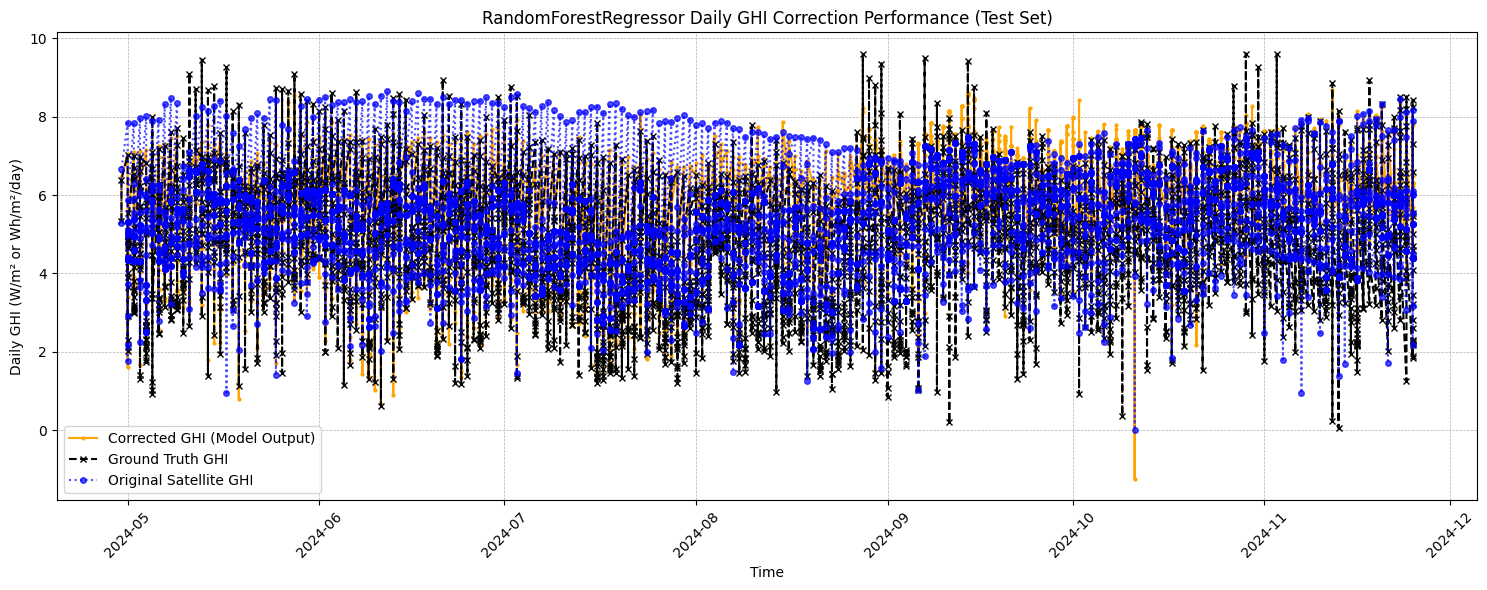


--- Quantile Mapping Benchmark ---
Applying Quantile Mapping...

--- Evaluating Quantile Mapping vs Ground Truth (Test Set) ---
--- Quantile Mapping Performance ---
RMSE: 1.1818
MAE:  0.8873
R²:   0.3895
MBE:  0.2314
KSI:  0.0931
------------------------------------
Latex version
Quantile Mapping & 1.1818 & 0.8873 & 0.3895 & 0.2314 & 0.0931 \\


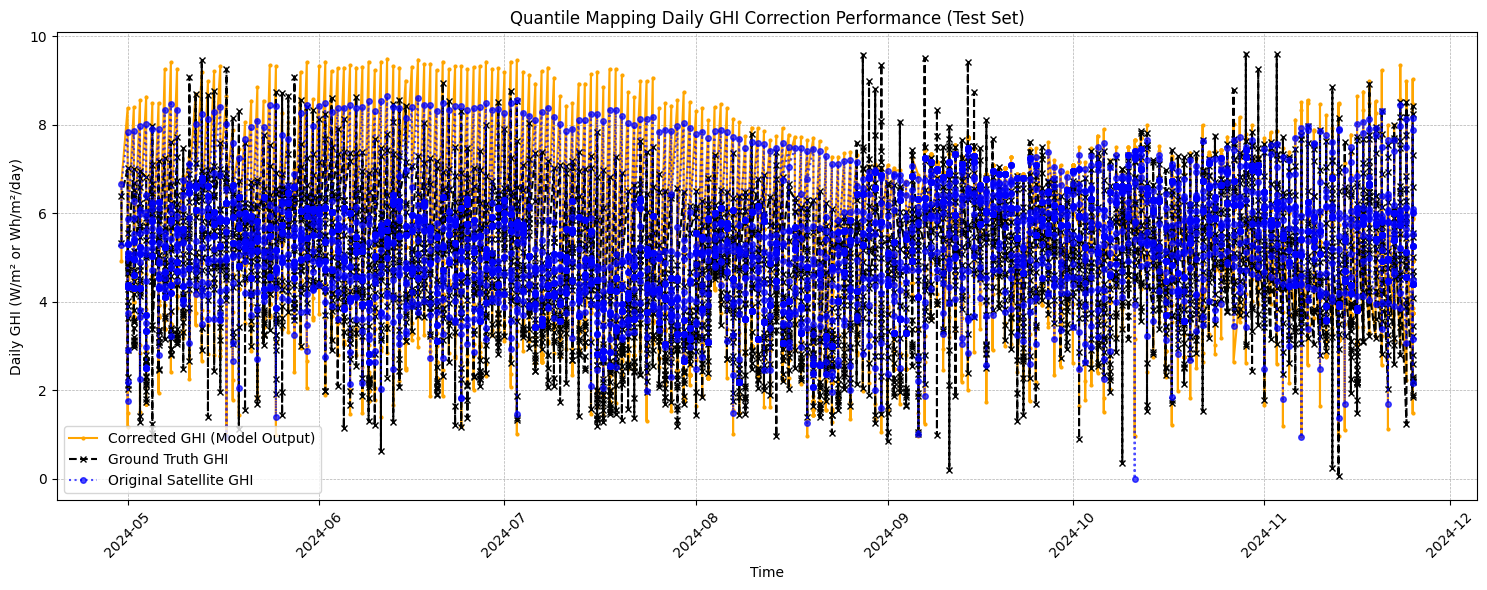


--- Feature Importance Analysis ---
           Feature  Importance
0          kt_cams    0.087207
1            DISPH    0.084351
2         ghi_cams    0.074265
3        ALLSKY_KT    0.072578
4         ghi_nasa    0.069291
5           EVLAND    0.036631
6         bhi_cams    0.035277
7          AIRMASS    0.031554
8           PBLTOP    0.029504
9      SRF_ALB_ADJ    0.028843
10         EVPTRNS    0.026153
11       CLOUD_AMT    0.023512
12        dni_nasa    0.022844
13             V2M    0.022229
14   dayofyear_cos    0.021819
15             TO3    0.021553
16             T2M    0.021364
17            RHOA    0.020531
18         GWETTOP    0.019744
19       T2M_RANGE    0.019671
20   dayofyear_sin    0.019082
21        altitude    0.018599
22      AOD_55_ADJ    0.018345
23              PW    0.017236
24     PRECTOTCORR    0.015838
25        dni_cams    0.015751
26  clear_ghi_nasa    0.015696
27            RH2M    0.015685
28        dhi_cams    0.014987
29  ghi_clear_cams    0.013213
30

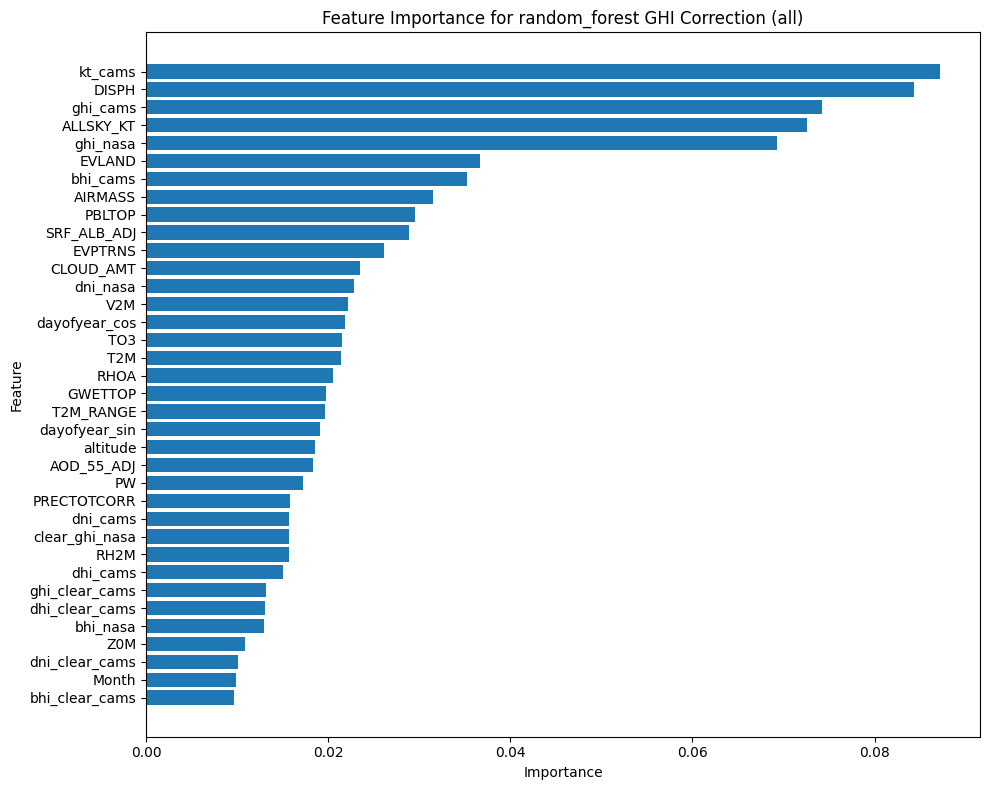


Pipeline finished.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib
import os

from sklearn.model_selection import train_test_split # Note: We won't use this directly for time series split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.interpolate import interp1d
from scipy.stats import ks_2samp

# ==============================================================================
# Helper Functions (Provided)
# ==============================================================================

def calculate_metrics(y_true, y_pred, model_name="Model", verbose=True, latex=False):
    """
    Calculates standard regression metrics including the Kolmogorov-Smirnov statistic (KSI).

    Args:
        y_true (array-like): Ground truth values.
        y_pred (array-like): Predicted values.
        model_name (str): Name of the model for printing.
        verbose (bool): Whether to print the metrics.
        latex (bool): Whether to print the metrics in LaTeX table format.

    Returns:
        dict: Dictionary containing the calculated metrics: RMSE, MAE, R2, MBE, KSI.
    """
    if verbose or latex:
        print(f"--- {model_name} Performance ---")
    # Ensure inputs are numpy arrays for consistency
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Handle potential NaNs or Infs in predictions if model fails
    valid_preds = np.isfinite(y_pred)
    if not np.all(valid_preds):
        print(f"Warning: Found {np.sum(~valid_preds)} non-finite predictions for {model_name}. Evaluating only on finite predictions.")
        y_true = y_true[valid_preds]
        y_pred = y_pred[valid_preds]
        if len(y_true) == 0:
            print("Error: No valid predictions left to evaluate.")
            return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "MBE": np.nan, "KSI": np.nan}


    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # Check if y_true has variance before calculating R2
    if np.var(y_true) > 1e-9: # Add a small tolerance
        r2 = r2_score(y_true, y_pred)
    else:
        print(f"Warning: Ground truth for {model_name} has near-zero variance. R² is not well-defined.")
        r2 = np.nan # Or handle as appropriate

    mbe = np.mean(y_pred - y_true) # Note: Prediction - True

    # Ensure there are enough samples for KS test
    if len(y_true) > 1 and len(y_pred) > 1:
         ks_stat, _ = ks_2samp(y_true, y_pred)
    else:
        print(f"Warning: Not enough samples for KS test for {model_name}")
        ks_stat = np.nan

    if verbose:
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")
        print(f"R²:   {r2:.4f}")
        print(f"MBE:  {mbe:.4f}")
        print(f"KSI:  {ks_stat:.4f}") # Print KSI
        if verbose or latex:
             print("-" * (len(model_name) + 20))

    if latex:
        print('Latex version')
        # Add KSI to the latex output
        print(f"{model_name} & {rmse:.4f} & {mae:.4f} & {r2:.4f} & {mbe:.4f} & {ks_stat:.4f} \\\\") # Added model name and latex formatting

    # Add KSI to the returned dictionary
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MBE": mbe, "KSI": ks_stat}

def plot_ghi_comparison(index, y_true, y_corrected, y_est, num_points=100, title="GHI Comparison"):
    """Plots the comparison of different GHI estimates."""
    plt.figure(figsize=(15, 6))
    # Ensure num_points doesn't exceed data length
    num_points = min(num_points, len(index))

    plt.plot(index[:num_points], y_corrected[:num_points], label='Corrected GHI (Model Output)', marker='.', linestyle='-', markersize=4, color='orange')
    plt.plot(index[:num_points], y_true[:num_points], label='Ground Truth GHI', marker='x', linestyle='--', markersize=4, color='black')
    plt.plot(index[:num_points], y_est[:num_points], label='Original Satellite GHI', marker='o', linestyle=':', markersize=4, color='blue', alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel("Daily GHI (W/m² or Wh/m²/day)") # Adjust unit based on data
    plt.title(title)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Main Correction Class (Provided)
# ==============================================================================

class SolarGHIErrorCorrection:
    """
    A class to handle the training, evaluation, and prediction for GHI error correction models.
    This allows saving the model and reusing it for future predictions without retraining.
    """

    def __init__(self, model_type='random_forest', model_params=None, save_path=None):
        """
        Initialize the error correction pipeline.

        Args:
            model_type (str): Type of model ('random_forest', 'linear', 'ridge', 'svr', 'xgboost')
            model_params (dict): Parameters for the selected model
            save_path (str): Directory to save the model and scaler
        """
        self.model_type = model_type
        self.model_params = model_params or {}
        self.save_path = save_path
        self.model = None
        self.scaler = None
        self.feature_cols = None
        self.ground_truth_col = None
        self.est_ghi_col = None
        self.is_trained = False

        # Create save directory if it doesn't exist
        if save_path and not os.path.exists(save_path):
            os.makedirs(save_path)

    def _create_model(self):
        """Create the model based on the specified type."""
        if self.model_type == 'random_forest':
            # Sensible defaults if not provided
            n_estimators = self.model_params.get('n_estimators', 100)
            max_depth = self.model_params.get('max_depth', 15)
            min_samples_leaf = self.model_params.get('min_samples_leaf', 5)
            random_state = self.model_params.get('random_state', 42)
            model_params_copy = self.model_params.copy()
            # Remove params handled explicitly to avoid duplication if passed in kwargs
            for key in ['n_estimators', 'max_depth', 'min_samples_leaf', 'random_state']:
                 model_params_copy.pop(key, None)
            return RandomForestRegressor(n_estimators=n_estimators,
                                        max_depth=max_depth,
                                        min_samples_leaf=min_samples_leaf,
                                        random_state=random_state,
                                        n_jobs=-1, # Use all available cores
                                        **model_params_copy) # Pass remaining params

        elif self.model_type == 'linear':
            return LinearRegression(**self.model_params)

        elif self.model_type == 'ridge':
            # Ensure default alpha if not provided
            if 'alpha' not in self.model_params:
                self.model_params['alpha'] = 1.0
            return Ridge(**self.model_params)

        elif self.model_type == 'svr':
            # Sensible defaults if not provided
            if 'kernel' not in self.model_params:
                self.model_params['kernel'] = 'rbf'
            if 'C' not in self.model_params:
                self.model_params['C'] = 1.0 # Regularization parameter
            if 'epsilon' not in self.model_params:
                self.model_params['epsilon'] = 0.1 # Margin of tolerance
            return SVR(**self.model_params)

        elif self.model_type == 'xgboost':
            # Sensible defaults if not provided
            if 'n_estimators' not in self.model_params:
                self.model_params['n_estimators'] = 100
            if 'learning_rate' not in self.model_params:
                self.model_params['learning_rate'] = 0.1
            if 'max_depth' not in self.model_params:
                self.model_params['max_depth'] = 5 # Slightly shallower default than RF
            if 'random_state' not in self.model_params:
                self.model_params['random_state'] = 42
            return xgb.XGBRegressor(objective='reg:squarederror', **self.model_params) # Specify objective

        else:
            raise ValueError(f"Unsupported model type: {self.model_type}")

    def train(self, df, feature_cols, ground_truth_col='ghi', est_ghi_col='ghi_nasa',
              test_size=0.2, scale_features=False, plot_comparison=True, num_plot_points=100, verbose=True, latex=False):
        """
        Train the model using a chronological split and optionally evaluate on a test set.

        Args:
            df (pd.DataFrame): DataFrame containing all necessary columns, MUST be sorted by time index.
            feature_cols (list): List of column names to use as features.
            ground_truth_col (str): Name of the ground truth GHI column.
            est_ghi_col (str): Name of the original satellite GHI column.
            test_size (float): Proportion of the data to use for the test set (taken from the end).
            scale_features (bool): Whether to apply StandardScaler to features.
            plot_comparison (bool): Whether to plot the test set results.
            num_plot_points (int): Number of points to show in the plot.
            verbose (bool): Print metrics during training evaluation.
            latex (bool): Print metrics in LaTeX format during training evaluation.


        Returns:
            dict: A dictionary containing performance metrics and test set predictions, or None if error.
        """
        # Store column names for future predictions
        self.feature_cols = feature_cols
        self.ground_truth_col = ground_truth_col
        self.est_ghi_col = est_ghi_col

        # Create a fresh model instance
        self.model = self._create_model()

        # Process data - ensure no NaNs in relevant columns
        required_cols = [ground_truth_col, est_ghi_col] + feature_cols
        df_processed = df.dropna(subset=required_cols).copy()

        if df_processed.empty:
            print("Error: DataFrame is empty after dropping NaNs. Check input data and feature list.")
            return None

        # Calculate error (target) = Ground Truth - Satellite Estimate
        target_col = 'bias'
        df_processed[target_col] = df_processed[self.ground_truth_col] - df_processed[self.est_ghi_col]

        # Prepare features and target
        X = df_processed[feature_cols]
        y = df_processed[target_col] # Predict the bias

        # Store original values for evaluation later
        original_est_ghi = df_processed[est_ghi_col]
        original_ground_truth = df_processed[ground_truth_col]

        # Chronological Split (IMPORTANT!)
        n_samples = len(X)
        n_test = int(n_samples * test_size)
        n_train = n_samples - n_test

        if n_train <= 0 or n_test <= 0:
             print(f"Error: Not enough data for train/test split (Train: {n_train}, Test: {n_test}). Need more data or smaller test_size.")
             return None

        X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
        y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]

        # Keep corresponding original GHI values for test set evaluation
        est_ghi_test = original_est_ghi.iloc[n_train:]
        ground_truth_test = original_ground_truth.iloc[n_train:]
        test_index = ground_truth_test.index # Use index from ground truth slice

        # Feature scaling if requested
        if scale_features:
            self.scaler = StandardScaler()
            X_train_scaled = self.scaler.fit_transform(X_train)
            # Use the *same* scaler fitted on train data to transform test data
            X_test_scaled = self.scaler.transform(X_test)
        else:
            self.scaler = None # Ensure scaler is None if not used
            X_train_scaled = X_train # Use original data if no scaling
            X_test_scaled = X_test

        # Train the model
        print(f"\nTraining {self.model.__class__.__name__} on {n_train} samples...")
        self.model.fit(X_train_scaled, y_train)

        print("Training complete.")
        self.is_trained = True

        # Save model and scaler if a path is provided
        if self.save_path:
            self._save_model()

        # --- Evaluate on test set ---
        print(f"\nEvaluating on {n_test} test samples...")
        error_pred_test = self.model.predict(X_test_scaled)

        # Corrected GHI = Satellite Estimate + Predicted Bias
        ghi_corrected_test = est_ghi_test + error_pred_test

        # Calculate metrics for the corrected model output
        if verbose or latex:
            print("\n--- Evaluating Model Corrected GHI vs Ground Truth (Test Set) ---")
        model_metrics = calculate_metrics(ground_truth_test, ghi_corrected_test, self.model.__class__.__name__, verbose=verbose, latex=latex)

        # Calculate metrics for the original satellite estimate (baseline)
        if verbose or latex:
            print(f"\n--- Evaluating Original Satellite GHI ({self.est_ghi_col}) vs Ground Truth (Test Set - Baseline) ---")
        baseline_metrics = calculate_metrics(ground_truth_test, est_ghi_test, f"Baseline ({self.est_ghi_col})", verbose=verbose, latex=latex)

        # Plot results if requested
        if plot_comparison:
            plot_ghi_comparison(
                test_index,
                ground_truth_test,
                ghi_corrected_test,
                est_ghi_test,
                num_points=min(num_plot_points, n_test), # Don't plot more points than available
                title=f"{self.model.__class__.__name__} Daily GHI Correction Performance (Test Set)"
            )

        # Return results dictionary
        return {
            "model_performance": model_metrics,
            "baseline_performance": baseline_metrics,
            "test_predictions": pd.DataFrame({ # Return predictions as DataFrame
                "ground_truth": ground_truth_test,
                "corrected_ghi": ghi_corrected_test,
                "satellite_ghi": est_ghi_test
            }, index=test_index)
        }

    def predict(self, df, return_error=False):
        """
        Make predictions with the trained model on new data.

        Args:
            df (pd.DataFrame): DataFrame containing the required feature columns and satellite GHI column.
            return_error (bool): If True, return the predicted error (bias) instead of corrected GHI.

        Returns:
            pd.Series: Corrected GHI values or predicted error values, indexed like the input df (after NaN drop).
        """
        if not self.is_trained:
            raise RuntimeError("Model is not trained. Call train() first or load a saved model.")

        # Ensure required columns are present
        required_cols = self.feature_cols + [self.est_ghi_col]
        if not all(col in df.columns for col in required_cols):
            missing = set(required_cols) - set(df.columns)
            raise ValueError(f"Missing required columns in input DataFrame for prediction: {missing}")

        # Drop rows with missing values in necessary columns to avoid prediction errors
        df_clean = df.dropna(subset=required_cols).copy()
        if df_clean.empty:
             print("Warning: Input DataFrame for prediction is empty after dropping NaNs based on required columns.")
             return pd.Series(dtype=float) # Return empty series

        # Extract features
        X = df_clean[self.feature_cols]

        # Apply scaling if a scaler was fitted during training
        if self.scaler is not None:
            X_scaled = self.scaler.transform(X)
        else:
            X_scaled = X # Use original features if no scaling was applied

        # Predict error (bias)
        predicted_error = self.model.predict(X_scaled)

        if return_error:
            return pd.Series(predicted_error, index=df_clean.index, name='predicted_bias')
        else:
            # Calculate corrected GHI = Satellite Estimate + Predicted Bias
            est_ghi = df_clean[self.est_ghi_col]
            corrected_ghi = est_ghi + predicted_error
            return pd.Series(corrected_ghi, index=df_clean.index, name='corrected_ghi')

    def evaluate(self, df, plot_results=True, num_plot_points=200, verbose=True, latex=True):
        """
        Evaluate model on new data that includes ground truth.

        Args:
            df (pd.DataFrame): DataFrame containing features, satellite GHI, and ground truth columns.
            plot_results (bool): Whether to plot comparison.
            num_plot_points (int): Number of points to show in the plot.
            verbose (bool): Print metrics.
            latex (bool): Print metrics in LaTeX format.

        Returns:
            dict: Dictionary containing performance metrics for model and baseline.
        """
        if not self.is_trained:
            raise RuntimeError("Model is not trained. Call train() first or load a saved model.")

        # Check for required columns including ground truth for evaluation
        required_cols = self.feature_cols + [self.est_ghi_col, self.ground_truth_col]
        if not all(col in df.columns for col in required_cols):
            missing = set(required_cols) - set(df.columns)
            raise ValueError(f"Missing required columns in input DataFrame for evaluation: {missing}")

        # Drop rows with missing values in any required column
        df_clean = df.dropna(subset=required_cols).copy()
        if df_clean.empty:
             print("Error: DataFrame for evaluation is empty after dropping NaNs.")
             return {"model_performance": None, "baseline_performance": None}


        # Get predictions for the clean evaluation data
        corrected_ghi = self.predict(df_clean, return_error=False)

        # Extract ground truth and original satellite GHI for the same clean index
        ground_truth = df_clean.loc[corrected_ghi.index, self.ground_truth_col]
        est_ghi = df_clean.loc[corrected_ghi.index, self.est_ghi_col]

        # Calculate metrics for the corrected model
        if verbose or latex:
            print("\n--- Evaluating Model Corrected GHI vs Ground Truth (Evaluation Data) ---")
        model_metrics = calculate_metrics(ground_truth, corrected_ghi, self.model.__class__.__name__, verbose=verbose, latex=latex)

        # Calculate metrics for the baseline (original satellite estimate)
        if verbose or latex:
            print(f"\n--- Evaluating Original Satellite GHI ({self.est_ghi_col}) vs Ground Truth (Evaluation Data - Baseline) ---")
        baseline_metrics = calculate_metrics(ground_truth, est_ghi, f"Baseline ({self.est_ghi_col})", verbose=verbose, latex=latex)

        # Plot results if requested
        if plot_results:
            plot_ghi_comparison(
                ground_truth.index, # Use index from ground_truth
                ground_truth,
                corrected_ghi,
                est_ghi,
                num_points=min(num_plot_points, len(ground_truth.index)),
                title=f"{self.model.__class__.__name__} Daily GHI Correction Performance (Evaluation Data)"
            )

        return {
            "model_performance": model_metrics,
            "baseline_performance": baseline_metrics
        }

    def _save_model(self):
        """Save the trained model, scaler, and metadata."""
        if not self.is_trained:
            print("Warning: Attempting to save an untrained model")
            return

        if not self.save_path:
            print("Warning: No save path specified, model not saved.")
            return

        try:
            # Save model
            model_path = os.path.join(self.save_path, f"{self.model_type}_model.joblib")
            joblib.dump(self.model, model_path)

            # Save scaler if exists
            if self.scaler is not None:
                scaler_path = os.path.join(self.save_path, f"{self.model_type}_scaler.joblib")
                joblib.dump(self.scaler, scaler_path)

            # Save metadata (feature columns and other configuration)
            metadata = {
                'feature_cols': self.feature_cols,
                'ground_truth_col': self.ground_truth_col,
                'est_ghi_col': self.est_ghi_col,
                'model_type': self.model_type,
                'model_params': self.model_params, # Save parameters used
                'scaler_used': self.scaler is not None # Flag if scaler was used
            }
            metadata_path = os.path.join(self.save_path, f"{self.model_type}_metadata.joblib")
            joblib.dump(metadata, metadata_path)

            print(f"Model, scaler (if used), and metadata saved to {self.save_path}")

        except Exception as e:
            print(f"Error saving model to {self.save_path}: {e}")


    def load_model(self, model_dir=None):
        """
        Load a previously saved model, scaler (if exists), and metadata.

        Args:
            model_dir (str): Directory where the model artifacts were saved. Defaults to self.save_path if set during init.
        """
        load_path = model_dir or self.save_path
        if not load_path:
            raise ValueError("No model directory specified for loading (pass model_dir or set save_path during init).")

        if not os.path.isdir(load_path):
             raise FileNotFoundError(f"Load directory not found: {load_path}")

        try:
            # Load metadata first to get configuration
            metadata_path = os.path.join(load_path, f"{self.model_type}_metadata.joblib")
            if not os.path.exists(metadata_path):
                 raise FileNotFoundError(f"Metadata file not found at {metadata_path}. Cannot determine configuration.")
            metadata = joblib.load(metadata_path)

            # Configure the instance based on loaded metadata
            self.feature_cols = metadata.get('feature_cols')
            self.ground_truth_col = metadata.get('ground_truth_col')
            self.est_ghi_col = metadata.get('est_ghi_col')
            self.model_params = metadata.get('model_params', {}) # Load saved params
            scaler_used = metadata.get('scaler_used', False)

            if not self.feature_cols or not self.ground_truth_col or not self.est_ghi_col:
                 print("Warning: Loaded metadata is missing essential column names.")

            # Load model
            model_path = os.path.join(load_path, f"{self.model_type}_model.joblib")
            if not os.path.exists(model_path):
                raise FileNotFoundError(f"Model file not found at {model_path}")
            self.model = joblib.load(model_path)

            # Load scaler only if metadata indicates it was used
            if scaler_used:
                scaler_path = os.path.join(load_path, f"{self.model_type}_scaler.joblib")
                if os.path.exists(scaler_path):
                    self.scaler = joblib.load(scaler_path)
                else:
                    print(f"Warning: Metadata indicates scaler was used, but scaler file not found at {scaler_path}. Scaler set to None.")
                    self.scaler = None
            else:
                 self.scaler = None # Ensure scaler is None if not used during training

            self.is_trained = True
            print(f"Model configuration and artifacts loaded successfully from {load_path}")

        except Exception as e:
            print(f"Error loading model from {load_path}: {e}")
            self.is_trained = False # Ensure state reflects load failure

# ==============================================================================
# Factory Functions (Provided)
# ==============================================================================

def create_random_forest_model(save_path=None, **kwargs):
    """Create a Random Forest model instance."""
    return SolarGHIErrorCorrection(model_type='random_forest', model_params=kwargs, save_path=save_path)

def create_linear_regression_model(save_path=None, **kwargs):
    """Create a Linear Regression model instance."""
    return SolarGHIErrorCorrection(model_type='linear', model_params=kwargs, save_path=save_path)

def create_ridge_regression_model(save_path=None, **kwargs):
    """Create a Ridge Regression model instance."""
    return SolarGHIErrorCorrection(model_type='ridge', model_params=kwargs, save_path=save_path)

def create_svr_model(save_path=None, **kwargs):
    """Create an SVR model instance."""
    return SolarGHIErrorCorrection(model_type='svr', model_params=kwargs, save_path=save_path)

def create_xgboost_model(save_path=None, **kwargs):
    """Create an XGBoost model instance."""
    return SolarGHIErrorCorrection(model_type='xgboost', model_params=kwargs, save_path=save_path)

# ==============================================================================
# Quantile Mapping Function (Benchmark)
# ==============================================================================

def apply_quantile_mapping(train_sat_ghi, train_ground_ghi, test_sat_ghi):
    """
    Applies Quantile Mapping based on Empirical CDFs from training data.

    Args:
        train_sat_ghi (pd.Series): Satellite GHI from the training period.
        train_ground_ghi (pd.Series): Ground truth GHI from the training period.
        test_sat_ghi (pd.Series): Satellite GHI from the testing period.

    Returns:
        pd.Series: Quantile-mapped GHI for the test period.
    """
    print("Applying Quantile Mapping...")
    # 1. Fit ECDFs on TRAINING data
    # Drop NaNs from training data before fitting ECDFs
    train_sat_ghi = train_sat_ghi.dropna()
    train_ground_ghi = train_ground_ghi.dropna()

    if train_sat_ghi.empty or train_ground_ghi.empty:
        print("Error: Training data for QM is empty after dropping NaNs.")
        return pd.Series(index=test_sat_ghi.index, dtype=float) # Return empty series

    ecdf_sat = ECDF(train_sat_ghi)
    # ecdf_ground = ECDF(train_ground_ghi) # We need the inverse of this

    # 2. Create inverse ECDF (Quantile Function) for ground truth using interpolation
    # Use percentiles from 0.1% to 99.9% for more robust interpolation at edges
    p = np.linspace(0.001, 0.999, 200) # Use more points for smoother interpolation
    xq = np.quantile(train_ground_ghi, p)

    # Use interp1d for creating the inverse CDF (quantile function)
    # bounds_error=False prevents errors if test data goes outside training range
    # fill_value uses min/max training quantiles for extrapolation
    inv_ecdf_ground = interp1d(p, xq, kind='linear', bounds_error=False, fill_value=(xq.min(), xq.max()))

    # 3. Apply QM to the TEST satellite data
    # Get probabilities (percentiles) from the satellite ECDF for the test data
    sat_prob_test = ecdf_sat(test_sat_ghi)

    # Map these probabilities through the inverse ground truth ECDF
    qm_corrected_ghi_test = inv_ecdf_ground(sat_prob_test)

    return pd.Series(qm_corrected_ghi_test, index=test_sat_ghi.index, name="qm_corrected_ghi")


# ==============================================================================
# Main Execution Block
# ==============================================================================

if __name__ == "__main__":

    df_daily = df.copy()
    LOCATION_NAME = 'all'
    df_daily['location'] = LOCATION_NAME
    GROUND_TRUTH_COL = 'ghi'
    SAVE_MODEL_DIR = f'./{LOCATION_NAME}_daily_model'
    SAT_ESTIMATE_COL = 'ghi_nasa'
    TEST_SET_SIZE = 0.2
    APPLY_SCALING = True


    print(f"\nUsing the following {len(feature_cols)} features:")
    print(feature_cols)

    # --- 4. Preprocessing ---
    df_daily = df.sort_index()

    # --- 5. Train and Evaluate ML Model ---
    print("\n--- ML Model Training and Evaluation ---")
    # Instantiate the model (e.g., Random Forest)
    ml_model = create_random_forest_model(
        save_path=SAVE_MODEL_DIR, # Set path for saving
        n_estimators=150,         # Example: Number of trees
        max_depth=20,             # Example: Max depth of trees
        min_samples_leaf=3,       # Example: Min samples in a leaf node
        random_state=42,
        # Add other relevant RF params if needed (e.g., max_features)
    )
    # Alternatively, try XGBoost:
    # ml_model = create_xgboost_model(
    #     save_path=SAVE_MODEL_DIR,
    #     n_estimators=150,
    #     learning_rate=0.05,
    #     max_depth=6,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     random_state=42
    # )

    # Train the model (includes internal chronological split and evaluation on test set)
    ml_results = ml_model.train(
        df=df_daily,
        feature_cols=feature_cols,
        ground_truth_col=GROUND_TRUTH_COL,
        est_ghi_col=SAT_ESTIMATE_COL,
        test_size=TEST_SET_SIZE,
        scale_features=APPLY_SCALING,
        plot_comparison=True,
        num_plot_points=len(df_daily), # Plot all points for daily data if desired
        verbose=True,
        latex=True # Print latex table row during training eval
    )

    # --- 6. Quantile Mapping Benchmark ---
    print("\n--- Quantile Mapping Benchmark ---")
    # Split data chronologically - MUST match the split used in ml_model.train
    n_samples_qm = len(df_daily)
    n_test_qm = int(n_samples_qm * TEST_SET_SIZE)
    n_train_qm = n_samples_qm - n_test_qm

    train_df_qm = df_daily.iloc[:n_train_qm]
    test_df_qm = df_daily.iloc[n_train_qm:]

    # Apply QM
    qm_corrected_ghi = apply_quantile_mapping(
        train_sat_ghi=train_df_qm[SAT_ESTIMATE_COL],
        train_ground_ghi=train_df_qm[GROUND_TRUTH_COL],
        test_sat_ghi=test_df_qm[SAT_ESTIMATE_COL]
    )

    # Evaluate QM results on the test set
    if not qm_corrected_ghi.isnull().all(): # Check if QM produced results
        print("\n--- Evaluating Quantile Mapping vs Ground Truth (Test Set) ---")
        qm_metrics = calculate_metrics(
            y_true=test_df_qm[GROUND_TRUTH_COL],
            y_pred=qm_corrected_ghi,
            model_name="Quantile Mapping",
            verbose=True,
            latex=True # Print latex table row for QM
        )

        # Optional: Plot QM results
        plot_ghi_comparison(
            index=test_df_qm.index,
            y_true=test_df_qm[GROUND_TRUTH_COL],
            y_corrected=qm_corrected_ghi,
            y_est=test_df_qm[SAT_ESTIMATE_COL],
            num_points=len(test_df_qm),
            title="Quantile Mapping Daily GHI Correction Performance (Test Set)"
        )
    else:
         print("Quantile Mapping did not produce valid results (likely due to NaNs).")
         qm_metrics = None

    # --- 7. Feature Importance Analysis ---
    if ml_results and ml_model.is_trained and hasattr(ml_model.model, 'feature_importances_'):
        print("\n--- Feature Importance Analysis ---")
        importances = ml_model.model.feature_importances_
        feature_names = ml_model.feature_cols # Use features stored in the trained model instance
        importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

        print(importance_df)

        # Plot feature importances
        plt.figure(figsize=(10, 8)) # Adjust size as needed
        plt.barh(importance_df['Feature'], importance_df['Importance'])
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.title(f"Feature Importance for {ml_model.model_type} GHI Correction ({LOCATION_NAME})")
        plt.gca().invert_yaxis() # Display most important features at the top
        plt.tight_layout()
        plt.show()

    # --- 8. Example: Load Saved Model and Predict/Evaluate (Optional) ---
    # if os.path.exists(SAVE_MODEL_DIR):
    #     print("\n--- Example: Loading and Evaluating Saved Model ---")
    #     loaded_model = SolarGHIErrorCorrection(model_type=ml_model.model_type) # Match type
    #     try:
    #         loaded_model.load_model(model_dir=SAVE_MODEL_DIR)
    #
    #         # You could evaluate on the same test data or a new dataset
    #         # For demonstration, evaluate on the test split again:
    #         n_samples_eval = len(df_daily)
    #         n_test_eval = int(n_samples_eval * TEST_SET_SIZE)
    #         eval_df = df_daily.iloc[n_samples_eval - n_test_eval:] # Get the test split
    #
    #         print(f"\nEvaluating loaded model on {len(eval_df)} samples...")
    #         loaded_results = loaded_model.evaluate(
    #             df=eval_df,
    #             plot_results=False, # Avoid replotting identical graphs
    #             verbose=True,
    #             latex=False
    #         )
    #     except Exception as e:
    #         print(f"Error loading or evaluating saved model: {e}")


    print("\nPipeline finished.")

## Model evaluation

Performing feature engineering...

Using the following 36 features:
['T2M', 'RH2M', 'AOD_55_ADJ', 'CLOUD_AMT', 'PW', 'dayofyear_sin', 'dayofyear_cos', 'PRECTOTCORR', 'T2M_RANGE', 'Z0M', 'V2M', 'AIRMASS', 'DISPH', 'altitude', 'EVPTRNS', 'PBLTOP', 'TO3', 'RHOA', 'SRF_ALB_ADJ', 'EVLAND', 'GWETTOP', 'ALLSKY_KT', 'ghi_clear_cams', 'bhi_clear_cams', 'dhi_clear_cams', 'dni_clear_cams', 'ghi_cams', 'bhi_cams', 'dhi_cams', 'dni_cams', 'Month', 'kt_cams', 'ghi_nasa', 'bhi_nasa', 'dni_nasa', 'clear_ghi_nasa']

Preprocessing data...
Dropped 0 rows due to NaNs.

--- ML Model (random_forest) Training and Evaluation ---
Applying StandardScaler to features...

Training random_forest with pre-defined parameters...
Model training complete.
Model artifacts saved to ./all_daily_model

Evaluating final model on 4510 test samples...

--- Evaluating Final Model vs Ground Truth (Test Set) ---
--- RandomForestRegressor Performance ---
RMSE: 1.4520
MAE:  1.0422
R²:   0.0784
MBE:  0.7479
KSI:  0.2333
-----------

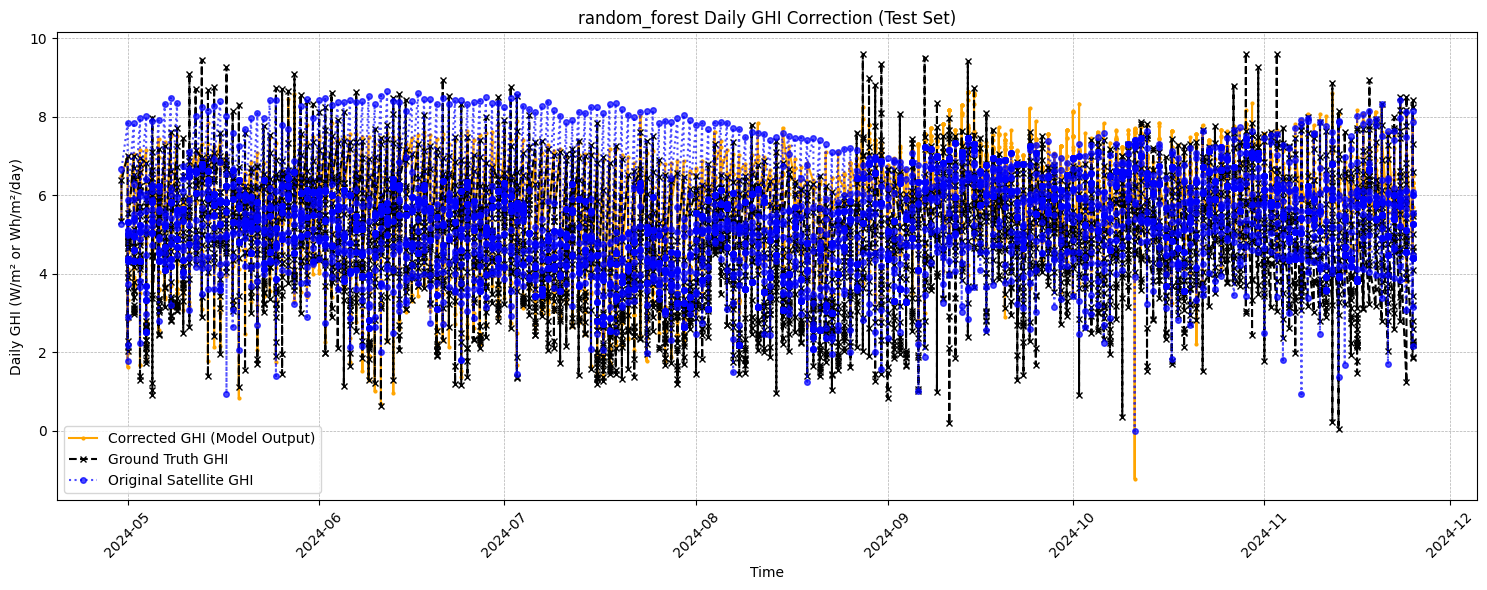

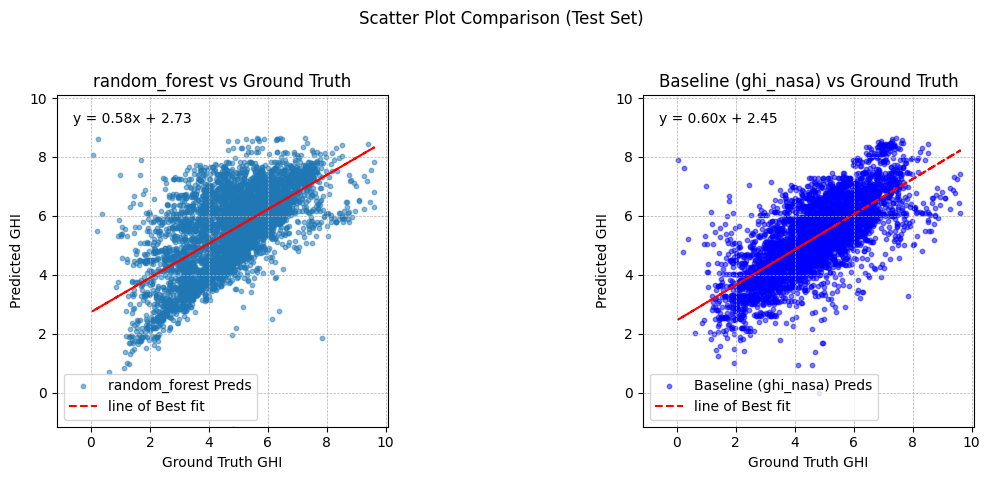

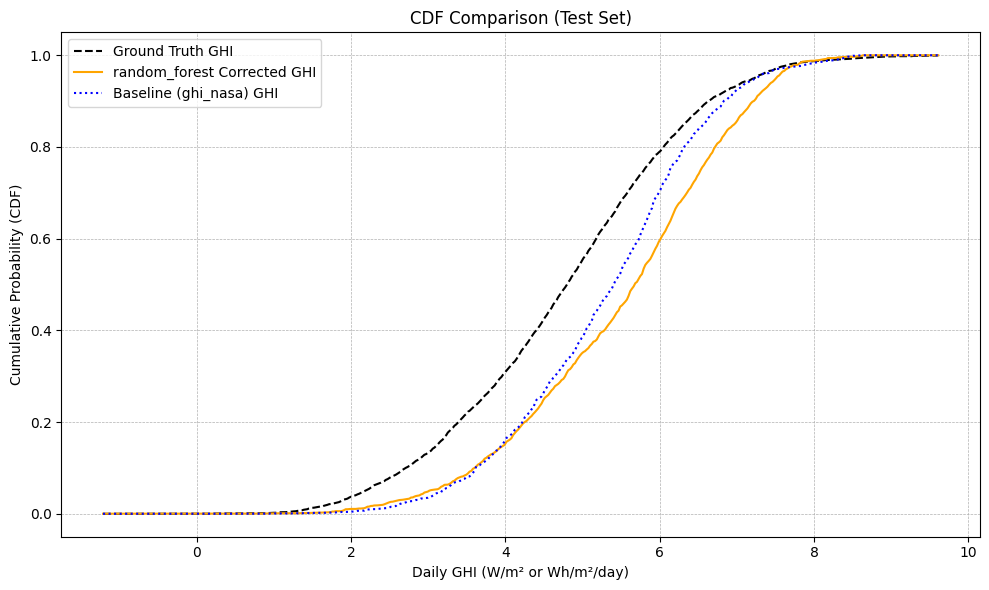


Combined Performance Index (CPI): 0.0235

--- Feature Importance Analysis ---
           Feature  Importance
0            DISPH    0.091449
1          kt_cams    0.090378
2         ghi_cams    0.077175
3        ALLSKY_KT    0.076601
4         ghi_nasa    0.071863
5           EVLAND    0.035097
6         bhi_cams    0.035057
7          AIRMASS    0.032009
8      SRF_ALB_ADJ    0.030829
9           PBLTOP    0.027498
10         EVPTRNS    0.027206
11       CLOUD_AMT    0.022693
12            RHOA    0.021983
13        dni_nasa    0.021590
14   dayofyear_cos    0.021459
15         GWETTOP    0.021046
16             V2M    0.020878
17             T2M    0.019935
18             TO3    0.019117
19        altitude    0.019047
20      AOD_55_ADJ    0.018343
21       T2M_RANGE    0.018307
22   dayofyear_sin    0.018110
23              PW    0.015607
24     PRECTOTCORR    0.015024
25  clear_ghi_nasa    0.014630
26        dni_cams    0.014560
27            RH2M    0.014232
28        dhi_cams    

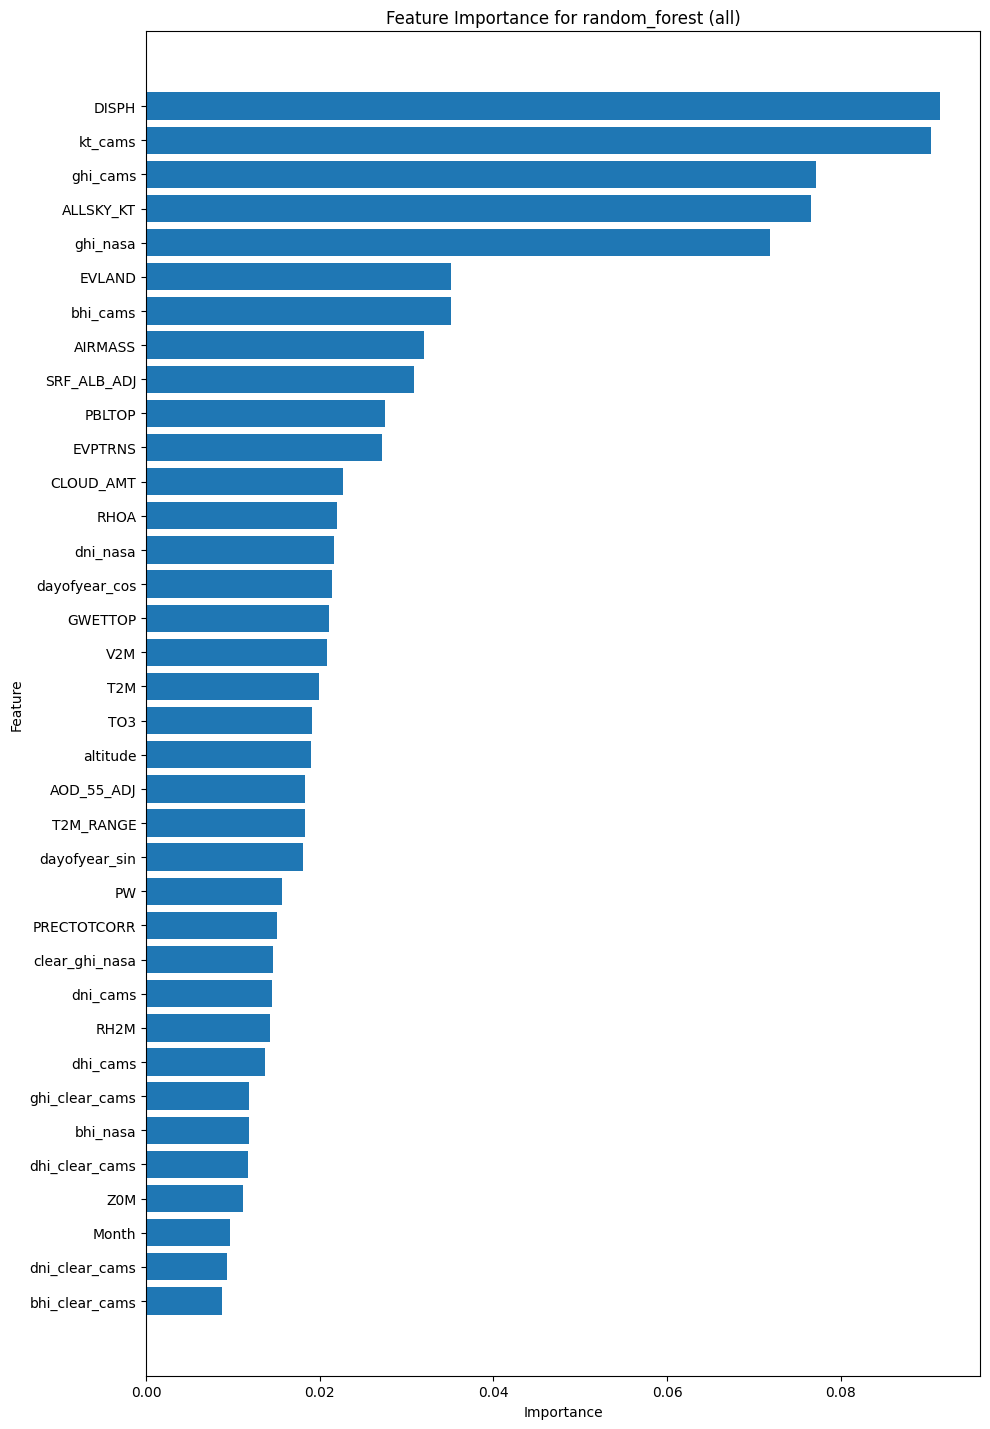


Pipeline finished.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib
import os
import warnings

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp

# Suppress specific warnings if needed (e.g., from plotting)
warnings.filterwarnings("ignore", category=UserWarning)

# ==============================================================================
# Helper Functions (Metrics, Plots, CPI)
# ==============================================================================

def calculate_metrics(y_true, y_pred, model_name="Model", verbose=True, latex=False):
    """
    Calculates standard regression metrics including the Kolmogorov-Smirnov statistic (KSI).

    Args:
        y_true (array-like): Ground truth values.
        y_pred (array-like): Predicted values.
        model_name (str): Name of the model for printing.
        verbose (bool): Whether to print the metrics.
        latex (bool): Whether to print the metrics in LaTeX table format.

    Returns:
        dict: Dictionary containing the calculated metrics: RMSE, MAE, R2, MBE, KSI.
    """
    if verbose or latex:
        print(f"--- {model_name} Performance ---")
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    valid_preds = np.isfinite(y_pred) & np.isfinite(y_true) # Check both true and pred
    if not np.all(valid_preds):
        num_invalid = np.sum(~valid_preds)
        print(f"Warning: Found {num_invalid} non-finite predictions or true values for {model_name}. Evaluating only on {len(y_true) - num_invalid} finite pairs.")
        y_true = y_true[valid_preds]
        y_pred = y_pred[valid_preds]
        if len(y_true) == 0:
            print(f"Error: No valid finite pairs left to evaluate for {model_name}.")
            return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "MBE": np.nan, "KSI": np.nan}

    if len(y_true) == 0: # Should be caught above, but double-check
         print(f"Error: Zero length arrays for evaluation for {model_name}.")
         return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "MBE": np.nan, "KSI": np.nan}


    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    if np.var(y_true) > 1e-9:
        r2 = r2_score(y_true, y_pred)
    else:
        print(f"Warning: Ground truth for {model_name} has near-zero variance. R² is NaN.")
        r2 = np.nan
    mbe = np.mean(y_pred - y_true)
    if len(y_true) > 1 and len(y_pred) > 1:
         ks_stat, _ = ks_2samp(y_true, y_pred)
    else:
        ks_stat = np.nan

    if verbose:
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")
        print(f"R²:   {r2:.4f}")
        print(f"MBE:  {mbe:.4f}")
        print(f"KSI:  {ks_stat:.4f}")
        if verbose or latex:
             print("-" * (len(model_name) + 20))
    if latex:
        print('Latex version')
        print(f"{model_name} & {rmse:.4f} & {mae:.4f} & {r2:.4f} & {mbe:.4f} & {ks_stat:.4f} \\\\")

    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MBE": mbe, "KSI": ks_stat}

def plot_ghi_comparison(index, y_true, y_corrected, y_est, num_points=100, title="GHI Comparison"):
    """Plots the comparison of different GHI estimates (Time Series Plot)."""
    plt.figure(figsize=(15, 6))
    num_points = min(num_points, len(index))
    plt.plot(index[:num_points], y_corrected[:num_points], label='Corrected GHI (Model Output)', marker='.', linestyle='-', markersize=4, color='orange')
    plt.plot(index[:num_points], y_true[:num_points], label='Ground Truth GHI', marker='x', linestyle='--', markersize=4, color='black')
    plt.plot(index[:num_points], y_est[:num_points], label='Original Satellite GHI', marker='o', linestyle=':', markersize=4, color='blue', alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel("Daily GHI (W/m² or Wh/m²/day)") # Adjust unit based on data
    plt.title(title)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_scatter_comparison(y_true, y_pred_model, y_pred_baseline, model_name, baseline_name, title="Scatter Plot Comparison"):
    """Plots scatter plots comparing model and baseline predictions to ground truth."""
    plt.figure(figsize=(12, 5))
    max_val = max(y_true.max(), y_pred_model.max(), y_pred_baseline.max()) * 1.05
    min_val = min(y_true.min(), y_pred_model.min(), y_pred_baseline.min()) * 0.95
    if min_val > 0: min_val = 0 # Ensure axes start near 0 if all values are positive

    # Plot Model vs True
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred_model, alpha=0.5, label=f'{model_name} Preds', s=10)

    # find line of best fit
    z = np.polyfit(y_true, y_pred_model, 1)
    p = np.poly1d(z)
    plt.plot(y_true, p(y_true), "r--", label='line of Best fit')
    # equation of estimate
    equation = f"y = {z[0]:.2f}x + {z[1]:.2f}"
    plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

    plt.xlabel("Ground Truth GHI")
    plt.ylabel("Predicted GHI")
    plt.title(f"{model_name} vs Ground Truth")
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')

    # Plot Baseline vs True
    plt.subplot(1, 2, 2)
    plt.scatter(y_true, y_pred_baseline, alpha=0.5, label=f'{baseline_name} Preds', s=10, color='blue')

    # find line of best fit
    z = np.polyfit(y_true, y_pred_baseline, 1)
    p = np.poly1d(z)
    plt.plot(y_true, p(y_true), "r--", label='line of Best fit')
    equation = f"y = {z[0]:.2f}x + {z[1]:.2f}"
    plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

    plt.xlabel("Ground Truth GHI")
    plt.ylabel("Predicted GHI")
    plt.title(f"{baseline_name} vs Ground Truth")
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')

    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

def plot_cdf_comparison(y_true, y_pred_model, y_pred_baseline, model_name, baseline_name, title="CDF Comparison"):
    """Plots empirical CDFs of ground truth, model predictions, and baseline predictions."""
    plt.figure(figsize=(10, 6))

    ecdf_true = ECDF(y_true)
    ecdf_model = ECDF(y_pred_model)
    ecdf_baseline = ECDF(y_pred_baseline)

    x_vals = np.linspace(min(y_true.min(), y_pred_model.min(), y_pred_baseline.min()),
                         max(y_true.max(), y_pred_model.max(), y_pred_baseline.max()),
                         500)

    plt.plot(x_vals, ecdf_true(x_vals), label='Ground Truth GHI', color='black', linestyle='--')
    plt.plot(x_vals, ecdf_model(x_vals), label=f'{model_name} Corrected GHI', color='orange', linestyle='-')
    plt.plot(x_vals, ecdf_baseline(x_vals), label=f'{baseline_name} GHI', color='blue', linestyle=':')

    plt.xlabel("Daily GHI (W/m² or Wh/m²/day)") # Adjust unit
    plt.ylabel("Cumulative Probability (CDF)")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

def calculate_cpi(model_metrics, baseline_metrics, weights={'RMSE': 0.4, 'MAE': 0.3, 'R2': 0.3}):
    """
    Calculates a Combined Performance Index (CPI) based on relative metric improvement.
    Higher CPI indicates better overall performance relative to the baseline.

    Args:
        model_metrics (dict): Metrics dictionary for the ML model.
        baseline_metrics (dict): Metrics dictionary for the baseline (e.g., raw satellite).
        weights (dict): Weights for combining normalized metrics (must sum to 1).

    Returns:
        float: The Combined Performance Index (CPI), or NaN if calculation fails.
    """
    cpi = 0.0
    total_weight = sum(weights.values())
    if not np.isclose(total_weight, 1.0):
        print("Warning: CPI weights do not sum to 1. Normalizing weights.")
        weights = {k: v / total_weight for k, v in weights.items()}

    # --- RMSE Relative Improvement ---
    rmse_model = model_metrics.get('RMSE')
    rmse_baseline = baseline_metrics.get('RMSE')
    if rmse_model is not None and rmse_baseline is not None and not np.isnan(rmse_model) and not np.isnan(rmse_baseline) and rmse_baseline > 1e-9:
        # Improvement: Higher is better. Max(0, ...) ensures no negative contribution if model is worse.
        rrmse_imp = max(0, (rmse_baseline - rmse_model) / rmse_baseline)
        cpi += weights.get('RMSE', 0) * rrmse_imp
        print(f"CPI: Relative RMSE Improvement = {rrmse_imp:.4f} (Weight: {weights.get('RMSE', 0)})")
    else:
        print("CPI: Cannot calculate relative RMSE improvement (NaN or zero baseline).")
        return np.nan # Cannot calculate CPI if essential component is missing

    # --- MAE Relative Improvement ---
    mae_model = model_metrics.get('MAE')
    mae_baseline = baseline_metrics.get('MAE')
    if mae_model is not None and mae_baseline is not None and not np.isnan(mae_model) and not np.isnan(mae_baseline) and mae_baseline > 1e-9:
        # Improvement: Higher is better.
        rmae_imp = max(0, (mae_baseline - mae_model) / mae_baseline)
        cpi += weights.get('MAE', 0) * rmae_imp
        print(f"CPI: Relative MAE Improvement = {rmae_imp:.4f} (Weight: {weights.get('MAE', 0)})")
    else:
        print("CPI: Cannot calculate relative MAE improvement (NaN or zero baseline).")
        return np.nan

    # --- R2 Score (Use directly, ensuring it's non-negative) ---
    r2_model = model_metrics.get('R2')
    if r2_model is not None and not np.isnan(r2_model):
        # Clamp R2 >= 0 for CPI calculation, as negative R2 indicates very poor fit.
        r2_term = max(0, r2_model)
        cpi += weights.get('R2', 0) * r2_term
        print(f"CPI: R2 Score contribution = {r2_term:.4f} (Weight: {weights.get('R2', 0)})")
    else:
        print("CPI: Cannot include R2 score (NaN).")
        return np.nan

    print(f"--- Final CPI = {cpi:.4f} ---")
    return cpi

# ==============================================================================
# Main Correction Class (Modified for Grid Search)
# ==============================================================================

class SolarGHIErrorCorrection:
    """
    (Docstring remains largely the same, handles training, evaluation, prediction)
    """
    def __init__(self, model_type='random_forest', model_params=None, save_path=None):
        # (Initialization remains the same)
        self.model_type = model_type
        self.model_params = model_params or {}
        self.save_path = save_path
        self.model = None
        self.scaler = None
        self.feature_cols = None
        self.ground_truth_col = None
        self.est_ghi_col = None
        self.is_trained = False
        self.best_params_ = None # Store best params found by GridSearch

        if save_path and not os.path.exists(save_path):
            os.makedirs(save_path)

    def _create_model(self, use_best_params=False):
        """Create the model, optionally using best_params_ found by GridSearch."""
        # Use stored best parameters if requested and available
        params_to_use = self.best_params_ if use_best_params and self.best_params_ else self.model_params

        # --- Model creation logic remains the same, but uses params_to_use ---
        if self.model_type == 'random_forest':
            n_estimators = params_to_use.get('n_estimators', 200)
            max_depth = params_to_use.get('max_depth', None)
            min_samples_leaf = params_to_use.get('min_samples_leaf', 5)
            random_state = params_to_use.get('random_state', 42)
            model_params_copy = params_to_use.copy()
            for key in ['n_estimators', 'max_depth', 'min_samples_leaf', 'random_state']:
                 model_params_copy.pop(key, None)
            return RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                                        random_state=random_state, n_jobs=-1, **model_params_copy)
        elif self.model_type == 'linear':
            return LinearRegression(**params_to_use)
        elif self.model_type == 'ridge':
            if 'alpha' not in params_to_use: params_to_use['alpha'] = 1.0
            return Ridge(**params_to_use)
        elif self.model_type == 'svr':
             if 'kernel' not in params_to_use: params_to_use['kernel'] = 'rbf'
             if 'C' not in params_to_use: params_to_use['C'] = 1.0
             if 'epsilon' not in params_to_use: params_to_use['epsilon'] = 0.1
             return SVR(**params_to_use)
        elif self.model_type == 'xgboost':
             if 'n_estimators' not in params_to_use: params_to_use['n_estimators'] = 100
             if 'learning_rate' not in params_to_use: params_to_use['learning_rate'] = 0.1
             if 'max_depth' not in params_to_use: params_to_use['max_depth'] = 5
             if 'random_state' not in params_to_use: params_to_use['random_state'] = 42
             return xgb.XGBRegressor(objective='reg:squarederror', **params_to_use)
        else:
            raise ValueError(f"Unsupported model type: {self.model_type}")

    def train(self, df, feature_cols, ground_truth_col='ghi', est_ghi_col='ALLSKY_SFC_SW_DWN',
              test_size=0.2, scale_features=False,
              use_grid_search=False, param_grid=None, cv_splits=3, cv_scoring='neg_root_mean_squared_error', # GridSearch args
              plot_comparison=True, num_plot_points=100, verbose=True, latex=False):
        """
        Train the model, optionally using GridSearchCV for hyperparameter tuning.

        Args:
            df (pd.DataFrame): DataFrame containing all necessary columns, MUST be sorted by time index.
            feature_cols (list): List of column names to use as features.
            ground_truth_col (str): Name of the ground truth GHI column.
            est_ghi_col (str): Name of the original satellite GHI column.
            test_size (float): Proportion of the data to use for the test set (taken from the end).
            scale_features (bool): Whether to apply StandardScaler to features.
            use_grid_search (bool): Whether to perform GridSearchCV.
            param_grid (dict): Parameter grid for GridSearchCV. Required if use_grid_search is True.
            cv_splits (int): Number of splits for TimeSeriesSplit cross-validation.
            cv_scoring (str): Scoring metric for GridSearchCV (e.g., 'neg_root_mean_squared_error', 'r2').
            plot_comparison (bool): Whether to plot the test set results.
            num_plot_points (int): Number of points to show in the plot.
            verbose (bool): Print progress and metrics.
            latex (bool): Print metrics in LaTeX format.

        Returns:
            dict: A dictionary containing performance metrics and test set predictions, or None if error.
        """
        # --- Initial processing and split (same as before) ---
        self.feature_cols = feature_cols
        self.ground_truth_col = ground_truth_col
        self.est_ghi_col = est_ghi_col

        required_cols = [ground_truth_col, est_ghi_col] + feature_cols
        df_processed = df.dropna(subset=required_cols).copy()
        if df_processed.empty:
            print("Error: DataFrame is empty after dropping NaNs. Check input data and feature list.")
            return None

        target_col = 'bias'
        df_processed[target_col] = df_processed[self.ground_truth_col] - df_processed[self.est_ghi_col]
        X = df_processed[feature_cols]
        y = df_processed[target_col]
        original_est_ghi = df_processed[est_ghi_col]
        original_ground_truth = df_processed[ground_truth_col]

        n_samples = len(X)
        n_test = int(n_samples * test_size)
        n_train = n_samples - n_test
        if n_train <= 0 or n_test <= 0:
             print(f"Error: Not enough data for train/test split (Train: {n_train}, Test: {n_test}). Need more data or smaller test_size.")
             return None

        X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
        y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]
        est_ghi_test = original_est_ghi.iloc[n_train:]
        ground_truth_test = original_ground_truth.iloc[n_train:]
        test_index = ground_truth_test.index

        # --- Feature Scaling (Applied before GridSearch/Training) ---
        if scale_features:
            if verbose: print("Applying StandardScaler to features...")
            self.scaler = StandardScaler()
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)
        else:
            self.scaler = None
            X_train_scaled = X_train.values # Ensure numpy array for consistency
            X_test_scaled = X_test.values

        # --- Model Training ---
        if use_grid_search:
            if not param_grid:
                raise ValueError("param_grid must be provided if use_grid_search is True.")

            print(f"\nPerforming GridSearchCV for {self.model_type}...")
            print(f"Parameter Grid: {param_grid}")
            print(f"CV Splits (TimeSeriesSplit): {cv_splits}")
            print(f"Scoring Metric: {cv_scoring}")

            base_estimator = self._create_model() # Create a base instance
            # TimeSeriesSplit is crucial for cross-validating time series data correctly
            tscv = TimeSeriesSplit(n_splits=cv_splits)

            grid_search = GridSearchCV(
                estimator=base_estimator,
                param_grid=param_grid,
                scoring=cv_scoring,
                cv=tscv,
                n_jobs=-1, # Use all available CPU cores
                verbose=1   # Show progress
            )

            # Fit GridSearch ONLY on the training data
            grid_search.fit(X_train_scaled, y_train)

            print("\nGridSearchCV Complete.")
            print(f"Best Parameters Found: {grid_search.best_params_}")
            print(f"Best CV Score ({cv_scoring}): {grid_search.best_score_:.4f}")

            self.best_params_ = grid_search.best_params_ # Store the best params
            self.model = grid_search.best_estimator_ # Use the best model found
            # Note: GridSearchCV automatically refits the best estimator on the whole training set by default

        else:
            # Train directly using initial or specified parameters
            print(f"\nTraining {self.model_type} with pre-defined parameters...")
            self.model = self._create_model() # Create instance with self.model_params
            self.model.fit(X_train_scaled, y_train)
            self.best_params_ = self.model_params # Store the params used

        print("Model training complete.")
        self.is_trained = True

        # Save model and scaler if a path is provided (Now includes best_params in metadata)
        if self.save_path:
            self._save_model() # Updated save includes best_params_

        # --- Evaluate on the held-out Test Set ---
        print(f"\nEvaluating final model on {n_test} test samples...")
        error_pred_test = self.model.predict(X_test_scaled)
        ghi_corrected_test = est_ghi_test + error_pred_test

        # --- Calculate Metrics ---
        if verbose or latex: print("\n--- Evaluating Final Model vs Ground Truth (Test Set) ---")
        model_metrics = calculate_metrics(ground_truth_test, ghi_corrected_test, self.model.__class__.__name__, verbose=verbose, latex=latex)

        if verbose or latex: print(f"\n--- Evaluating Baseline ({self.est_ghi_col}) vs Ground Truth (Test Set) ---")
        baseline_metrics = calculate_metrics(ground_truth_test, est_ghi_test, f"Baseline ({self.est_ghi_col})", verbose=verbose, latex=latex)

        # --- Store results ---
        results_dict = {
            "model_performance": model_metrics,
            "baseline_performance": baseline_metrics,
            "test_predictions": pd.DataFrame({
                "ground_truth": ground_truth_test,
                "corrected_ghi": ghi_corrected_test,
                "satellite_ghi": est_ghi_test
            }, index=test_index),
            "best_params": self.best_params_ # Include best params in results
        }

        # --- Plotting (using test set data) ---
        if plot_comparison:
            # Time Series Plot
            plot_ghi_comparison(
                index=results_dict["test_predictions"].index,
                y_true=results_dict["test_predictions"]["ground_truth"],
                y_corrected=results_dict["test_predictions"]["corrected_ghi"],
                y_est=results_dict["test_predictions"]["satellite_ghi"],
                num_points=min(num_plot_points, n_test),
                title=f"{self.model.__class__.__name__} Daily GHI Correction (Test Set)"
            )
            # Scatter Plot
            plot_scatter_comparison(
                 y_true=results_dict["test_predictions"]["ground_truth"],
                 y_pred_model=results_dict["test_predictions"]["corrected_ghi"],
                 y_pred_baseline=results_dict["test_predictions"]["satellite_ghi"],
                 model_name=self.model.__class__.__name__,
                 baseline_name=f"Baseline ({self.est_ghi_col})",
                 title="Scatter Plot Comparison (Test Set)"
            )
            # CDF Plot
            plot_cdf_comparison(
                 y_true=results_dict["test_predictions"]["ground_truth"],
                 y_pred_model=results_dict["test_predictions"]["corrected_ghi"],
                 y_pred_baseline=results_dict["test_predictions"]["satellite_ghi"],
                 model_name=self.model.__class__.__name__,
                 baseline_name=f"Baseline ({self.est_ghi_col})",
                 title="CDF Comparison (Test Set)"
            )

        # --- Calculate CPI ---
        if model_metrics and baseline_metrics and not any(np.isnan(m) for m in model_metrics.values()) and not any(np.isnan(m) for m in baseline_metrics.values()):
             print("\n--- Combined Performance Index (CPI) Calculation ---")
             cpi = calculate_cpi(model_metrics, baseline_metrics)
             results_dict["cpi"] = cpi
        else:
             print("\nSkipping CPI calculation due to missing or NaN metrics.")
             results_dict["cpi"] = np.nan


        return results_dict

    # --- predict, evaluate, _save_model, load_model methods remain largely the same ---
    # Minor update to _save_model to include best_params_
    def _save_model(self):
        """Save the trained model, scaler, and metadata including best params."""
        if not self.is_trained: print("Warning: Untrained model"); return
        if not self.save_path: print("Warning: No save path"); return
        try:
            model_path = os.path.join(self.save_path, f"{self.model_type}_model.joblib")
            joblib.dump(self.model, model_path)
            if self.scaler is not None:
                scaler_path = os.path.join(self.save_path, f"{self.model_type}_scaler.joblib")
                joblib.dump(self.scaler, scaler_path)
            metadata = {
                'feature_cols': self.feature_cols, 'ground_truth_col': self.ground_truth_col,
                'est_ghi_col': self.est_ghi_col, 'model_type': self.model_type,
                'model_params': self.model_params, # Initial params
                'best_params_': self.best_params_, # Best params found (could be same as initial if no GS)
                'scaler_used': self.scaler is not None
            }
            metadata_path = os.path.join(self.save_path, f"{self.model_type}_metadata.joblib")
            joblib.dump(metadata, metadata_path)
            print(f"Model artifacts saved to {self.save_path}")
        except Exception as e: print(f"Error saving model: {e}")

    # Load model needs to potentially read best_params_ too
    def load_model(self, model_dir=None):
        """Loads model, scaler, and metadata including best params."""
        load_path = model_dir or self.save_path
        if not load_path or not os.path.isdir(load_path): raise FileNotFoundError(f"Load directory not found: {load_path}")
        try:
            metadata_path = os.path.join(load_path, f"{self.model_type}_metadata.joblib")
            if not os.path.exists(metadata_path): raise FileNotFoundError(f"Metadata file not found: {metadata_path}")
            metadata = joblib.load(metadata_path)

            self.feature_cols = metadata.get('feature_cols')
            self.ground_truth_col = metadata.get('ground_truth_col')
            self.est_ghi_col = metadata.get('est_ghi_col')
            self.model_params = metadata.get('model_params', {})
            self.best_params_ = metadata.get('best_params_', None) # Load best params
            scaler_used = metadata.get('scaler_used', False)

            model_path = os.path.join(load_path, f"{self.model_type}_model.joblib")
            if not os.path.exists(model_path): raise FileNotFoundError(f"Model file not found: {model_path}")
            # Important: Recreate the model using the *best* parameters if they exist
            self.model = self._create_model(use_best_params=True)
            # Now load the state of the fitted model
            self.model = joblib.load(model_path)

            if scaler_used:
                scaler_path = os.path.join(load_path, f"{self.model_type}_scaler.joblib")
                if os.path.exists(scaler_path): self.scaler = joblib.load(scaler_path)
                else: print(f"Warning: Scaler file not found at {scaler_path}"); self.scaler = None
            else: self.scaler = None

            self.is_trained = True
            print(f"Model loaded from {load_path}. Best params: {self.best_params_}")
        except Exception as e: print(f"Error loading model: {e}"); self.is_trained = False

    # --- predict and evaluate methods remain the same ---
    def predict(self, df, return_error=False):
        """(No changes needed here)"""
        if not self.is_trained: raise RuntimeError("Model not trained.")
        required_cols = self.feature_cols + [self.est_ghi_col]
        if not all(col in df.columns for col in required_cols): raise ValueError(f"Missing columns: {set(required_cols) - set(df.columns)}")
        df_clean = df.dropna(subset=required_cols).copy()
        if df_clean.empty: return pd.Series(dtype=float)
        X = df_clean[self.feature_cols]
        X_scaled = self.scaler.transform(X) if self.scaler else X
        predicted_error = self.model.predict(X_scaled)
        if return_error: return pd.Series(predicted_error, index=df_clean.index, name='predicted_bias')
        else: return pd.Series(df_clean[self.est_ghi_col] + predicted_error, index=df_clean.index, name='corrected_ghi')

    def evaluate(self, df, plot_results=True, num_plot_points=200, verbose=True, latex=True):
        """(No changes needed here)"""
        if not self.is_trained: raise RuntimeError("Model not trained.")
        required_cols = self.feature_cols + [self.est_ghi_col, self.ground_truth_col]
        if not all(col in df.columns for col in required_cols): raise ValueError(f"Missing columns: {set(required_cols) - set(df.columns)}")
        df_clean = df.dropna(subset=required_cols).copy()
        if df_clean.empty: return {"model_performance": None, "baseline_performance": None}
        corrected_ghi = self.predict(df_clean)
        ground_truth = df_clean.loc[corrected_ghi.index, self.ground_truth_col]
        est_ghi = df_clean.loc[corrected_ghi.index, self.est_ghi_col]
        if verbose or latex: print("\n--- Evaluating Model Corrected GHI vs Ground Truth (Evaluation Data) ---")
        model_metrics = calculate_metrics(ground_truth, corrected_ghi, self.model.__class__.__name__, verbose=verbose, latex=latex)
        if verbose or latex: print(f"\n--- Evaluating Baseline ({self.est_ghi_col}) vs Ground Truth (Evaluation Data) ---")
        baseline_metrics = calculate_metrics(ground_truth, est_ghi, f"Baseline ({self.est_ghi_col})", verbose=verbose, latex=latex)
        if plot_results:
            plot_ghi_comparison(ground_truth.index, ground_truth, corrected_ghi, est_ghi, num_points=min(num_plot_points, len(ground_truth.index)), title=f"{self.model.__class__.__name__} GHI Correction (Evaluation Data)")
            plot_scatter_comparison(ground_truth, corrected_ghi, est_ghi, self.model.__class__.__name__, f"Baseline ({self.est_ghi_col})", "Scatter Plot Comparison (Evaluation Data)")
            plot_cdf_comparison(ground_truth, corrected_ghi, est_ghi, self.model.__class__.__name__, f"Baseline ({self.est_ghi_col})", "CDF Comparison (Evaluation Data)")
        return {"model_performance": model_metrics, "baseline_performance": baseline_metrics}


# ==============================================================================
# Factory Functions (Provided)
# ==============================================================================
def create_random_forest_model(save_path=None, **kwargs): return SolarGHIErrorCorrection(model_type='random_forest', model_params=kwargs, save_path=save_path)
def create_linear_regression_model(save_path=None, **kwargs): return SolarGHIErrorCorrection(model_type='linear', model_params=kwargs, save_path=save_path)
def create_ridge_regression_model(save_path=None, **kwargs): return SolarGHIErrorCorrection(model_type='ridge', model_params=kwargs, save_path=save_path)
def create_svr_model(save_path=None, **kwargs): return SolarGHIErrorCorrection(model_type='svr', model_params=kwargs, save_path=save_path)
def create_xgboost_model(save_path=None, **kwargs): return SolarGHIErrorCorrection(model_type='xgboost', model_params=kwargs, save_path=save_path)


# ==============================================================================
# Main Execution Block (User's updated start + GridSearch + New Plots/CPI)
# ==============================================================================

if __name__ == "__main__":

    LOCATION_NAME = 'all' # As per user's update
    SAVE_MODEL_DIR = f'./{LOCATION_NAME}_daily_model' # Directory to save the best model

    GROUND_TRUTH_COL = 'ghi'              # Column name for ground measurements
    # Assuming 'ghi_nasa' is the intended satellite column based on user snippet
    SAT_ESTIMATE_COL = 'ghi_nasa'         # Make sure this column exists in your CSV!
    # Need corresponding clear-sky and DoY columns for feature engineering
    SAT_CLEARSKY_COL = 'CLRSKY_SFC_SW_DWN'# Assumed clear-sky column name
    DOY_COL = 'DoY'                       # Assumed Day of Year column name

    TEST_SET_SIZE = 0.2 # Proportion of data held out for final testing
    APPLY_SCALING = True # Standardize features
    CLEAR_SKY_KT_THRESHOLD = 0.7 # Threshold for 'is_clear' feature
    PERFORM_GRID_SEARCH = False # Set to True to run GridSearch
    CV_SPLITS = 3              # Number of splits for TimeSeriesSplit in GridSearch


    # --- 3. Feature Engineering (Daily - Option B) ---
    print("Performing feature engineering...")
    df = df.copy()
    if DOY_COL not in df.columns:
        if hasattr(df.index, 'dayofyear'): df[DOY_COL] = df.index.dayofyear
        else: print(f"Error: '{DOY_COL}' missing."); exit()
    df['dayofyear_sin'] = np.sin(2 * np.pi * df[DOY_COL] / 365.25)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df[DOY_COL] / 365.25)
    if SAT_CLEARSKY_COL in df.columns and SAT_ESTIMATE_COL in df.columns:
        df['kt_nasa'] = np.where(df[SAT_CLEARSKY_COL] > 1e-6, df[SAT_ESTIMATE_COL] / df[SAT_CLEARSKY_COL], 0)
        df['kt_nasa'] = df['kt_nasa'].clip(lower=0, upper=1.2)
    else: df['kt_nasa'] = np.nan # Set to NaN if cannot calculate
    if not df['kt_nasa'].isnull().all():
        df['is_clear'] = (df['kt_nasa'] > CLEAR_SKY_KT_THRESHOLD).astype(int)
    else: df['is_clear'] = np.nan # Set to NaN if cannot calculate


    print(f"\nUsing the following {len(feature_cols)} features:")
    print(feature_cols)

    # --- 4. Preprocessing ---
    print("\nPreprocessing data...")
    df_daily = df.sort_index()
    initial_rows = len(df_daily)
    print(f"Dropped {initial_rows - len(df_daily)} rows due to NaNs.")
    if df_daily.empty: print("Error: DataFrame empty after preprocessing."); exit()

    # --- 5. Define Model and Grid Search Parameters ---
    MODEL_TYPE = 'random_forest' # Or 'xgboost'

    # Define parameter grid for the chosen model
    param_grid = {}
    if PERFORM_GRID_SEARCH:
        if MODEL_TYPE == 'random_forest':
            param_grid = {
                'n_estimators': [100, 150, 200],
                'max_depth': [15, 20, 25, None], # None means nodes expand until pure or min_samples_leaf
                'min_samples_leaf': [3, 5, 7],
                'max_features': ['sqrt', 0.7, 1.0] # Different options for features to consider at split
            }
        elif MODEL_TYPE == 'xgboost':
             param_grid = {
                 'n_estimators': [100, 150, 200],
                 'learning_rate': [0.03, 0.05, 0.1],
                 'max_depth': [4, 5, 6, 7],
                 'subsample': [0.7, 0.8, 0.9],
                 'colsample_bytree': [0.7, 0.8, 0.9]
             }
        # Add grids for other model types if needed

    # Instantiate the chosen model type
    if MODEL_TYPE == 'random_forest':
        ml_model = create_random_forest_model(save_path=SAVE_MODEL_DIR, random_state=42) # Base params here don't matter much if using GS
    elif MODEL_TYPE == 'xgboost':
         ml_model = create_xgboost_model(save_path=SAVE_MODEL_DIR, random_state=42)
    else:
         # Add other model types or raise error
         print(f"Error: Grid search not defined for model type {MODEL_TYPE}")
         exit()


    # --- 6. Train and Evaluate ML Model ( Potentially with GridSearch ) ---
    print(f"\n--- ML Model ({MODEL_TYPE}) Training and Evaluation ---")
    ml_results = ml_model.train(
        df=df_daily,
        feature_cols=feature_cols,
        ground_truth_col=GROUND_TRUTH_COL,
        est_ghi_col=SAT_ESTIMATE_COL,
        test_size=TEST_SET_SIZE,
        scale_features=APPLY_SCALING,
        use_grid_search=PERFORM_GRID_SEARCH, # Control grid search execution
        param_grid=param_grid,             # Pass the defined grid
        cv_splits=CV_SPLITS,               # Number of time series splits for CV
        cv_scoring='neg_root_mean_squared_error', # Metric to optimize in CV
        plot_comparison=False,             # Plotting moved after training call
        num_plot_points=len(df_daily),     # Prepare for full plotting
        verbose=True,
        latex=True
    )

    # --- 7. Post-Training Analysis (Plots, CPI, Feature Importance) ---
    if ml_results:
        print("\n--- Post-Training Analysis ---")

        # Extract test set predictions
        test_preds_df = ml_results['test_predictions']
        y_true_test = test_preds_df['ground_truth']
        y_corr_test = test_preds_df['corrected_ghi']
        y_sat_test = test_preds_df['satellite_ghi']

        # Generate Plots
        print("Generating plots...")
        # Time Series Plot (using the function from helper)
        plot_ghi_comparison(test_preds_df.index, y_true_test, y_corr_test, y_sat_test, num_points=len(test_preds_df), title=f"{MODEL_TYPE} Daily GHI Correction (Test Set)")
        # Scatter Plot
        plot_scatter_comparison(y_true_test, y_corr_test, y_sat_test, MODEL_TYPE, f"Baseline ({SAT_ESTIMATE_COL})", "Scatter Plot Comparison (Test Set)")
        # CDF Plot
        plot_cdf_comparison(y_true_test, y_corr_test, y_sat_test, MODEL_TYPE, f"Baseline ({SAT_ESTIMATE_COL})", "CDF Comparison (Test Set)")

        # Display CPI if calculated
        if 'cpi' in ml_results:
            print(f"\nCombined Performance Index (CPI): {ml_results['cpi']:.4f}")
        else:
            # Attempt calculation again if metrics are now available
            if ml_results['model_performance'] and ml_results['baseline_performance']:
                 cpi = calculate_cpi(ml_results['model_performance'], ml_results['baseline_performance'])
                 if not np.isnan(cpi): print(f"\nCombined Performance Index (CPI): {cpi:.4f}")


        # Feature Importance Analysis
        if ml_model.is_trained and hasattr(ml_model.model, 'feature_importances_'):
            print("\n--- Feature Importance Analysis ---")
            importances = ml_model.model.feature_importances_
            feature_names = ml_model.feature_cols # Use features stored in the instance
            importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
            print(importance_df)

            plt.figure(figsize=(10, max(6, len(feature_names)*0.4))) # Adjust height based on num features
            plt.barh(importance_df['Feature'], importance_df['Importance'])
            plt.xlabel("Importance")
            plt.ylabel("Feature")
            plt.title(f"Feature Importance for {MODEL_TYPE} ({LOCATION_NAME})")
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
        else:
             print("\nFeature importance not available for this model type or model not trained.")

    else:
        print("\nML model training failed. Skipping post-training analysis.")

    # Optional: Quantile Mapping skipped based on user feedback.

    print("\nPipeline finished.")

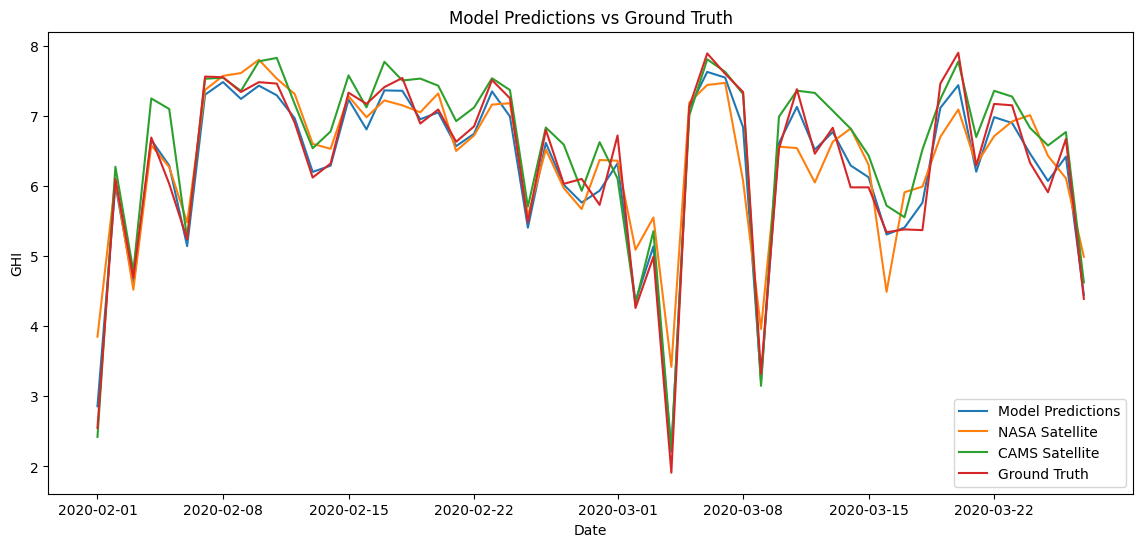

In [14]:
# plot predictions of the model againt ground, nasa and cams ghi
soroti_ghi_pred = ml_model.predict(soroti)
fig, ax = plt.subplots(figsize=(14, 6))
cutoff = 56
# Assuming 'soroti_ghi_pred' has a DatetimeIndex, use .iloc for position-based slicing:
ax.plot(soroti_ghi_pred.index[:cutoff], soroti_ghi_pred.iloc[:cutoff], label='Model Predictions')
ax.plot(soroti.index[:cutoff], soroti['ghi_nasa'].iloc[:cutoff], label='NASA Satellite')
ax.plot(soroti.index[:cutoff], soroti['ghi_cams'].iloc[:cutoff], label='CAMS Satellite')
ax.plot(soroti.index[:cutoff], soroti['ghi'].iloc[:cutoff], label='Ground Truth')
ax.set_xlabel('Date')
ax.set_ylabel('GHI')
ax.set_title('Model Predictions vs Ground Truth')
ax.legend()
plt.show()

Performing feature engineering...

Using the following 36 features:
['T2M', 'RH2M', 'AOD_55_ADJ', 'CLOUD_AMT', 'PW', 'dayofyear_sin', 'dayofyear_cos', 'PRECTOTCORR', 'T2M_RANGE', 'Z0M', 'V2M', 'AIRMASS', 'DISPH', 'altitude', 'EVPTRNS', 'PBLTOP', 'TO3', 'RHOA', 'SRF_ALB_ADJ', 'EVLAND', 'GWETTOP', 'ALLSKY_KT', 'ghi_clear_cams', 'bhi_clear_cams', 'dhi_clear_cams', 'dni_clear_cams', 'ghi_cams', 'bhi_cams', 'dhi_cams', 'dni_cams', 'Month', 'kt_cams', 'ghi_nasa', 'bhi_nasa', 'dni_nasa', 'clear_ghi_nasa']

Preprocessing data...
Dropped 0 rows due to NaNs.

--- ML Model (xgboost) Training and Evaluation ---
Applying StandardScaler to features...

Training xgboost with pre-defined parameters...
Model training complete.
Model artifacts saved to ./all_daily_model

Evaluating final model on 4510 test samples...

--- Evaluating Final Model vs Ground Truth (Test Set) ---
--- XGBRegressor Performance ---
RMSE: 1.1091
MAE:  0.8157
R²:   0.4623
MBE:  0.4372
KSI:  0.1643
--------------------------------

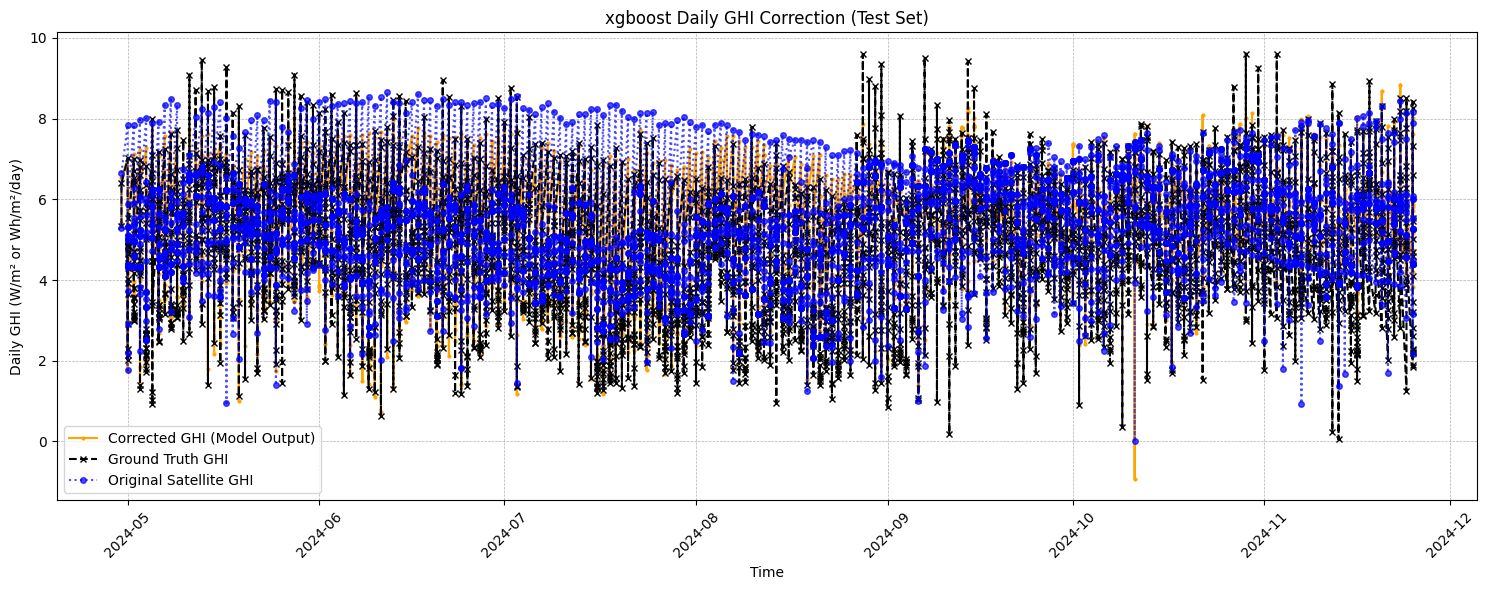

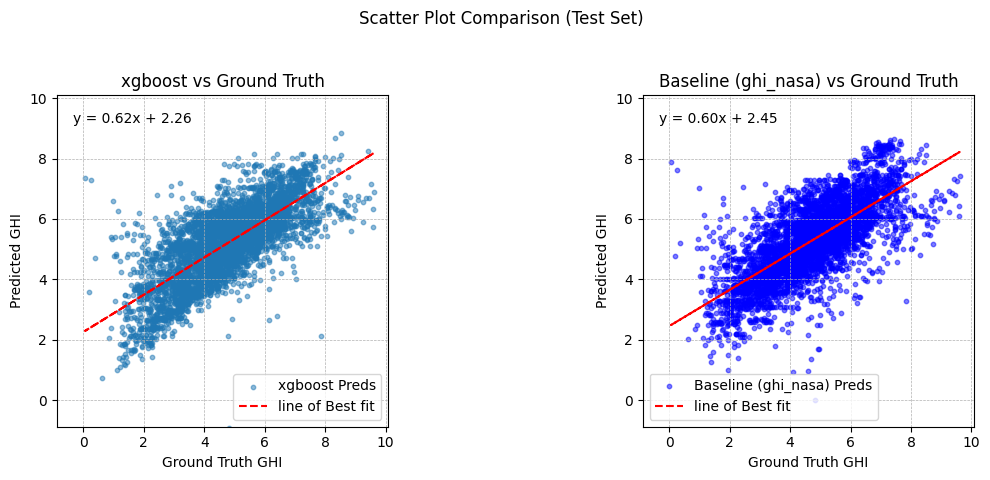

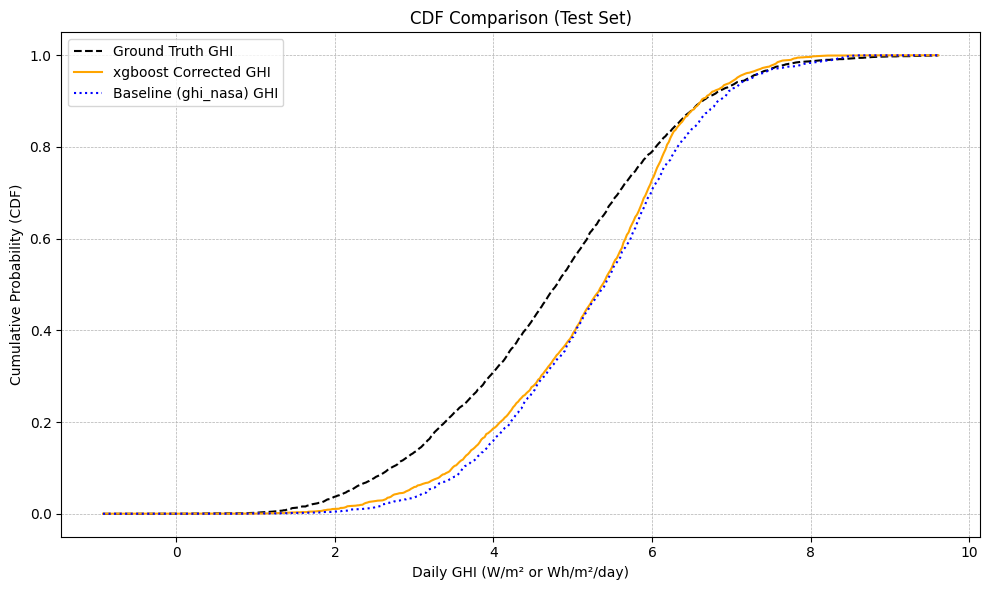


Combined Performance Index (CPI): 0.2011

--- Feature Importance Analysis ---
           Feature  Importance
0              Z0M    0.091198
1            DISPH    0.080512
2           EVLAND    0.057172
3         ghi_cams    0.056079
4        ALLSKY_KT    0.055822
5          kt_cams    0.050570
6      SRF_ALB_ADJ    0.044327
7         altitude    0.043767
8         bhi_cams    0.043675
9          EVPTRNS    0.041062
10            RHOA    0.034229
11        ghi_nasa    0.032776
12           Month    0.029797
13        dni_nasa    0.029419
14       CLOUD_AMT    0.026128
15         AIRMASS    0.024844
16          PBLTOP    0.019188
17   dayofyear_cos    0.018548
18  dni_clear_cams    0.016002
19         GWETTOP    0.015940
20      AOD_55_ADJ    0.013912
21       T2M_RANGE    0.013721
22             V2M    0.013607
23  bhi_clear_cams    0.013535
24             T2M    0.013528
25        dni_cams    0.012663
26  dhi_clear_cams    0.012441
27  clear_ghi_nasa    0.012374
28             TO3    

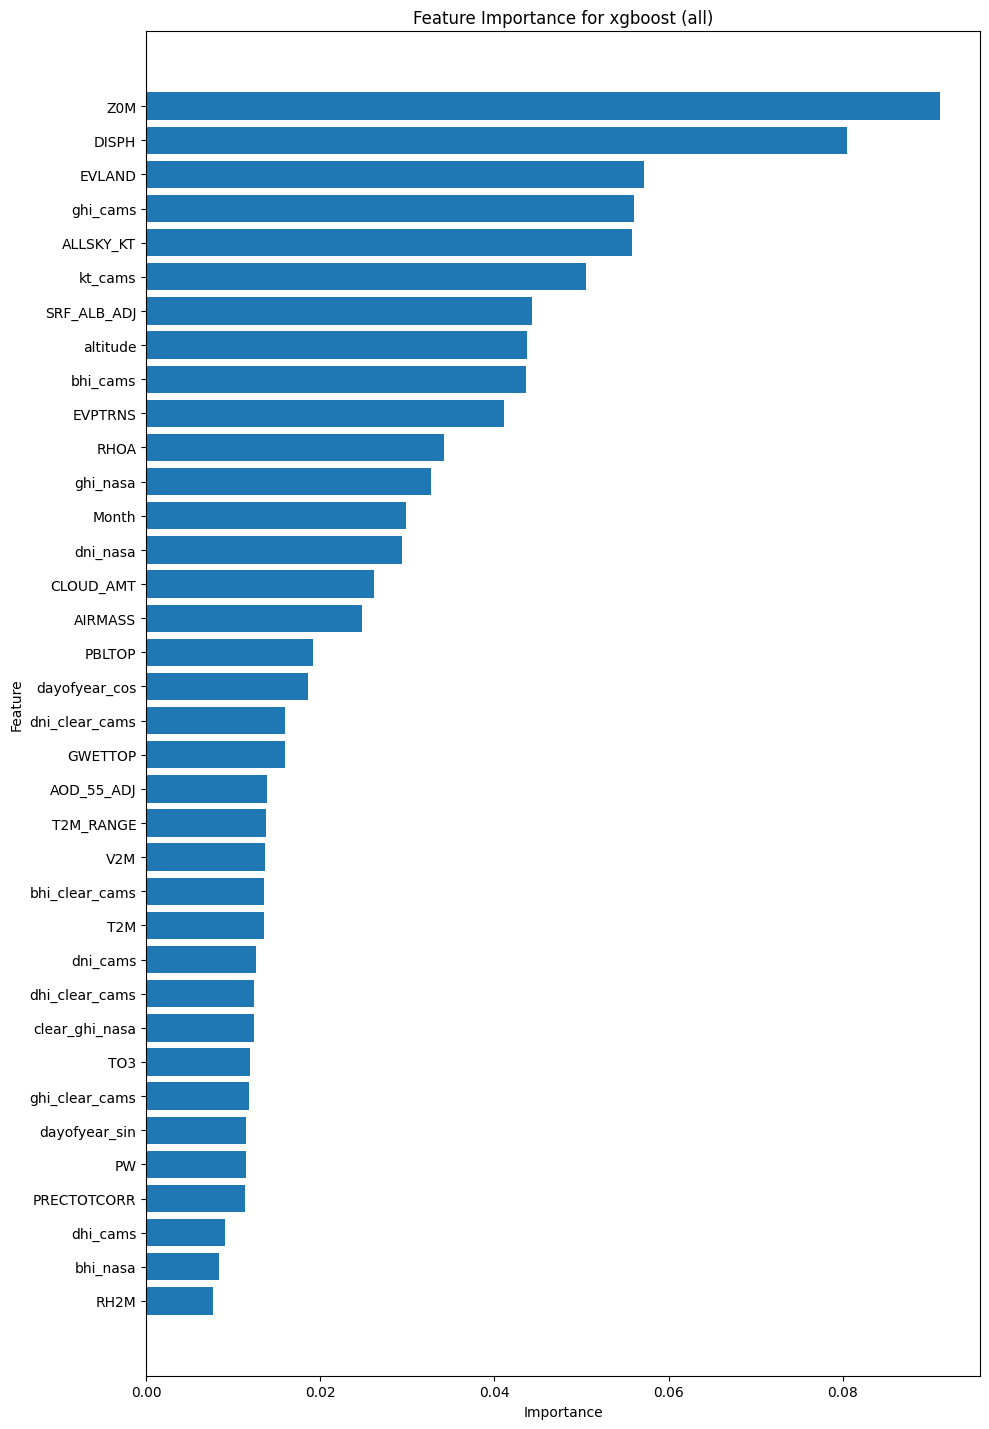


Pipeline finished.


In [15]:
# ==============================================================================
# Main Execution Block (User's updated start + GridSearch + New Plots/CPI)
# ==============================================================================

if __name__ == "__main__":

    LOCATION_NAME = 'all' # As per user's update
    SAVE_MODEL_DIR = f'./{LOCATION_NAME}_daily_model' # Directory to save the best model

    GROUND_TRUTH_COL = 'ghi'              # Column name for ground measurements
    # Assuming 'ghi_nasa' is the intended satellite column based on user snippet
    SAT_ESTIMATE_COL = 'ghi_nasa'         # Make sure this column exists in your CSV!
    # Need corresponding clear-sky and DoY columns for feature engineering
    SAT_CLEARSKY_COL = 'CLRSKY_SFC_SW_DWN'# Assumed clear-sky column name
    DOY_COL = 'DoY'                       # Assumed Day of Year column name

    TEST_SET_SIZE = 0.2 # Proportion of data held out for final testing
    APPLY_SCALING = True # Standardize features
    CLEAR_SKY_KT_THRESHOLD = 0.7 # Threshold for 'is_clear' feature
    PERFORM_GRID_SEARCH = False # Set to True to run GridSearch
    CV_SPLITS = 3             # Number of splits for TimeSeriesSplit in GridSearch


    # --- 3. Feature Engineering (Daily - Option B) ---
    print("Performing feature engineering...")
    df = df.copy()
    if DOY_COL not in df.columns:
        if hasattr(df.index, 'dayofyear'): df[DOY_COL] = df.index.dayofyear
        else: print(f"Error: '{DOY_COL}' missing."); exit()
    df['dayofyear_sin'] = np.sin(2 * np.pi * df[DOY_COL] / 365.25)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df[DOY_COL] / 365.25)
    if SAT_CLEARSKY_COL in df.columns and SAT_ESTIMATE_COL in df.columns:
        df['kt_nasa'] = np.where(df[SAT_CLEARSKY_COL] > 1e-6, df[SAT_ESTIMATE_COL] / df[SAT_CLEARSKY_COL], 0)
        df['kt_nasa'] = df['kt_nasa'].clip(lower=0, upper=1.2)
    else: df['kt_nasa'] = np.nan # Set to NaN if cannot calculate
    if not df['kt_nasa'].isnull().all():
        df['is_clear'] = (df['kt_nasa'] > CLEAR_SKY_KT_THRESHOLD).astype(int)
    else: df['is_clear'] = np.nan # Set to NaN if cannot calculate


    print(f"\nUsing the following {len(feature_cols)} features:")
    print(feature_cols)

    # --- 4. Preprocessing ---
    print("\nPreprocessing data...")
    df_daily = df.sort_index()
    initial_rows = len(df_daily)
    print(f"Dropped {initial_rows - len(df_daily)} rows due to NaNs.")
    if df_daily.empty: print("Error: DataFrame empty after preprocessing."); exit()

    # --- 5. Define Model and Grid Search Parameters ---
    MODEL_TYPE = 'xgboost'

    # Define parameter grid for the chosen model
    param_grid = {}
    if PERFORM_GRID_SEARCH:
        if MODEL_TYPE == 'random_forest':
            param_grid = {
                'n_estimators': [100, 150, 200],
                'max_depth': [15, 20, 25, None], # None means nodes expand until pure or min_samples_leaf
                'min_samples_leaf': [3, 5, 7],
                'max_features': ['sqrt', 0.7, 1.0] # Different options for features to consider at split
            }
        elif MODEL_TYPE == 'xgboost':
             param_grid = {
                 'n_estimators': [100, 150, 200],
                 'learning_rate': [0.03, 0.05, 0.1],
                 'max_depth': [4, 5, 6, 7],
                 'subsample': [0.7, 0.8, 0.9],
                 'colsample_bytree': [0.7, 0.8, 0.9]
             }
        # Add grids for other model types if needed

    # Instantiate the chosen model type
    MODEL_TYPE = 'xgboost'
    xgboost_model = create_xgboost_model(save_path=SAVE_MODEL_DIR, random_state=42)


    # --- 6. Train and Evaluate ML Model ( Potentially with GridSearch ) ---
    print(f"\n--- ML Model ({MODEL_TYPE}) Training and Evaluation ---")
    ml_results = xgboost_model.train(
        df=df_daily,
        feature_cols=feature_cols,
        ground_truth_col=GROUND_TRUTH_COL,
        est_ghi_col=SAT_ESTIMATE_COL,
        test_size=TEST_SET_SIZE,
        scale_features=APPLY_SCALING,
        use_grid_search=PERFORM_GRID_SEARCH, # Control grid search execution
        param_grid=param_grid,             # Pass the defined grid
        cv_splits=CV_SPLITS,               # Number of time series splits for CV
        cv_scoring='neg_root_mean_squared_error', # Metric to optimize in CV
        plot_comparison=False,             # Plotting moved after training call
        num_plot_points=len(df_daily),     # Prepare for full plotting
        verbose=True,
        latex=True
    )

    # --- 7. Post-Training Analysis (Plots, CPI, Feature Importance) ---
    if ml_results:
        print("\n--- Post-Training Analysis ---")

        # Extract test set predictions
        test_preds_df = ml_results['test_predictions']
        y_true_test = test_preds_df['ground_truth']
        y_corr_test = test_preds_df['corrected_ghi']
        y_sat_test = test_preds_df['satellite_ghi']

        # Generate Plots
        print("Generating plots...")
        # Time Series Plot (using the function from helper)
        plot_ghi_comparison(test_preds_df.index, y_true_test, y_corr_test, y_sat_test, num_points=len(test_preds_df), title=f"{MODEL_TYPE} Daily GHI Correction (Test Set)")
        # Scatter Plot
        plot_scatter_comparison(y_true_test, y_corr_test, y_sat_test, MODEL_TYPE, f"Baseline ({SAT_ESTIMATE_COL})", "Scatter Plot Comparison (Test Set)")
        # CDF Plot
        plot_cdf_comparison(y_true_test, y_corr_test, y_sat_test, MODEL_TYPE, f"Baseline ({SAT_ESTIMATE_COL})", "CDF Comparison (Test Set)")

        # Display CPI if calculated
        if 'cpi' in ml_results:
            print(f"\nCombined Performance Index (CPI): {ml_results['cpi']:.4f}")
        else:
            # Attempt calculation again if metrics are now available
            if ml_results['model_performance'] and ml_results['baseline_performance']:
                 cpi = calculate_cpi(ml_results['model_performance'], ml_results['baseline_performance'])
                 if not np.isnan(cpi): print(f"\nCombined Performance Index (CPI): {cpi:.4f}")


        # Feature Importance Analysis
        if xgboost_model.is_trained and hasattr(xgboost_model.model, 'feature_importances_'):
            print("\n--- Feature Importance Analysis ---")
            importances = xgboost_model.model.feature_importances_
            feature_names = xgboost_model.feature_cols # Use features stored in the instance
            importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
            print(importance_df)

            plt.figure(figsize=(10, max(6, len(feature_names)*0.4))) # Adjust height based on num features
            plt.barh(importance_df['Feature'], importance_df['Importance'])
            plt.xlabel("Importance")
            plt.ylabel("Feature")
            plt.title(f"Feature Importance for {MODEL_TYPE} ({LOCATION_NAME})")
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
        else:
             print("\nFeature importance not available for this model type or model not trained.")

    else:
        print("\nML model training failed. Skipping post-training analysis.")

    # Optional: Quantile Mapping skipped based on user feedback.

    print("\nPipeline finished.")

Performing feature engineering...

Using the following 36 features:
['T2M', 'RH2M', 'AOD_55_ADJ', 'CLOUD_AMT', 'PW', 'dayofyear_sin', 'dayofyear_cos', 'PRECTOTCORR', 'T2M_RANGE', 'Z0M', 'V2M', 'AIRMASS', 'DISPH', 'altitude', 'EVPTRNS', 'PBLTOP', 'TO3', 'RHOA', 'SRF_ALB_ADJ', 'EVLAND', 'GWETTOP', 'ALLSKY_KT', 'ghi_clear_cams', 'bhi_clear_cams', 'dhi_clear_cams', 'dni_clear_cams', 'ghi_cams', 'bhi_cams', 'dhi_cams', 'dni_cams', 'Month', 'kt_cams', 'ghi_nasa', 'bhi_nasa', 'dni_nasa', 'clear_ghi_nasa']

Preprocessing data...
Dropped 0 rows due to NaNs.

--- ML Model (SVR) Training and Evaluation ---
Applying StandardScaler to features...

Training svr with pre-defined parameters...
Model training complete.
Model artifacts saved to ./all_daily_model

Evaluating final model on 4510 test samples...

--- Evaluating Final Model vs Ground Truth (Test Set) ---
--- SVR Performance ---
RMSE: 1.0196
MAE:  0.7340
R²:   0.5456
MBE:  0.3152
KSI:  0.1049
-----------------------
Latex version
SVR & 1.019

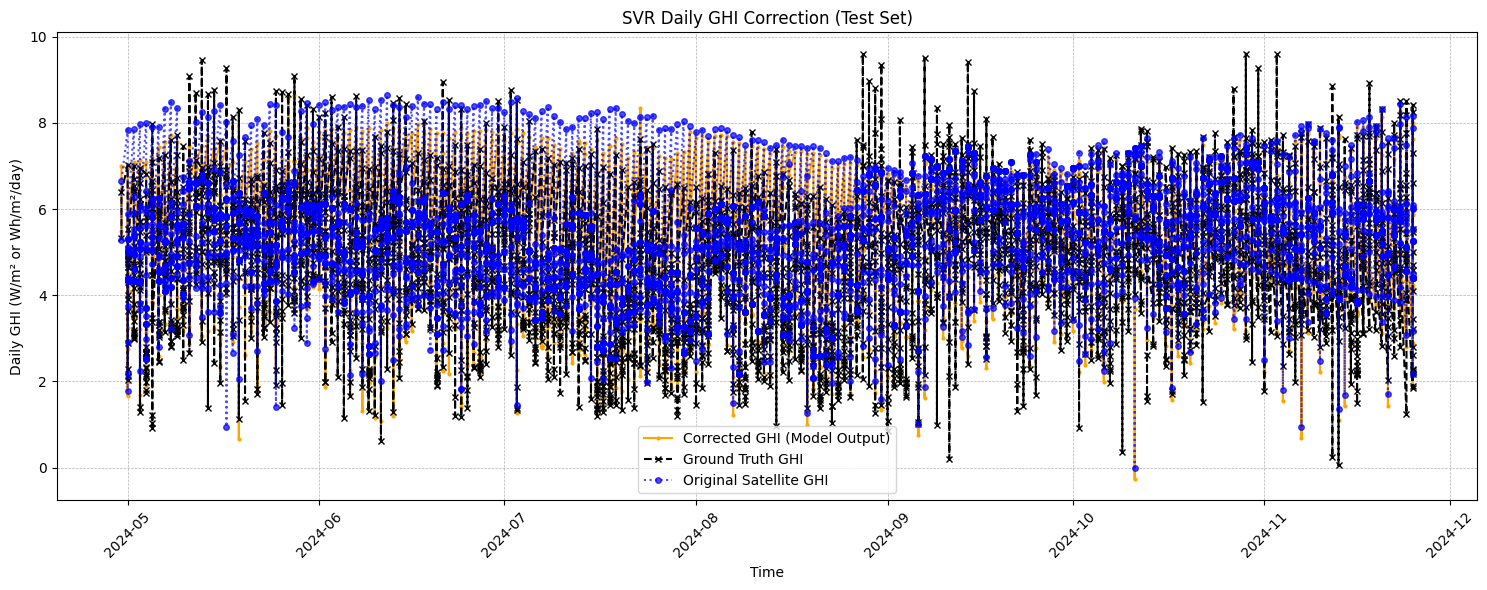

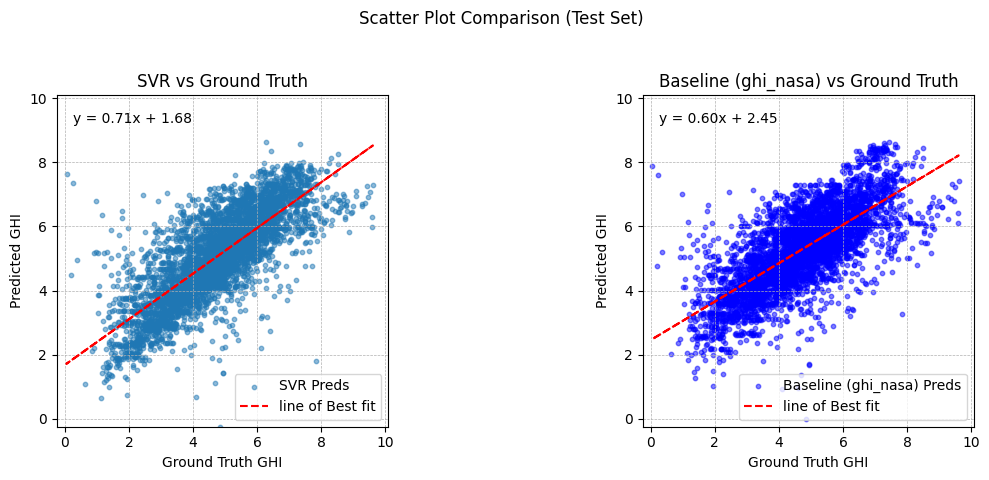

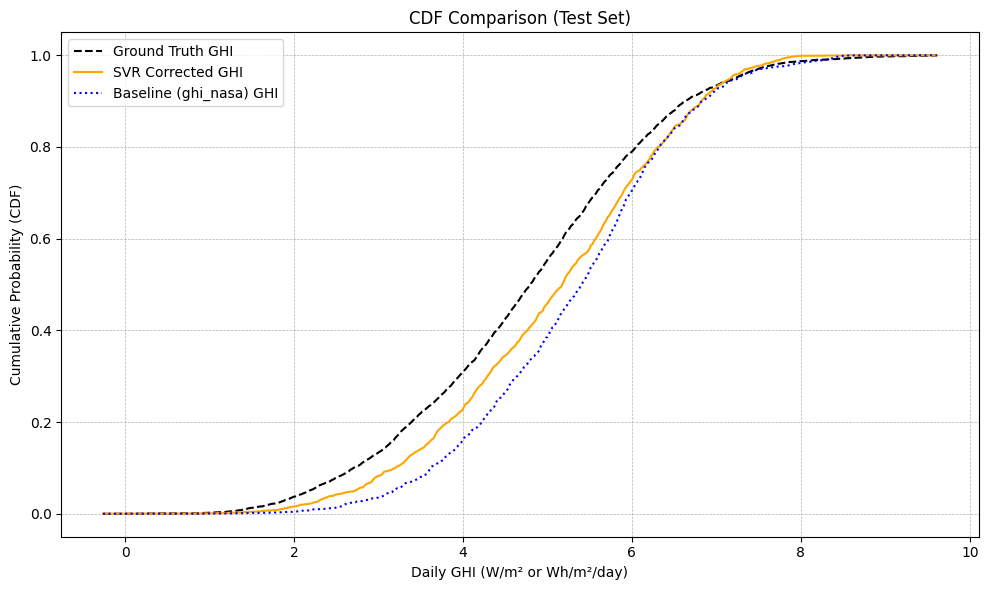


Combined Performance Index (CPI): 0.2827

Feature importance not available for this model type or model not trained.

Pipeline finished.


In [16]:
# ==============================================================================
# Main Execution Block (User's updated start + GridSearch + New Plots/CPI)
# ==============================================================================

if __name__ == "__main__":

    LOCATION_NAME = 'all' # As per user's update
    SAVE_MODEL_DIR = f'./{LOCATION_NAME}_daily_model' # Directory to save the best model

    GROUND_TRUTH_COL = 'ghi'              # Column name for ground measurements
    # Assuming 'ghi_nasa' is the intended satellite column based on user snippet
    SAT_ESTIMATE_COL = 'ghi_nasa'         # Make sure this column exists in your CSV!
    # Need corresponding clear-sky and DoY columns for feature engineering
    SAT_CLEARSKY_COL = 'CLRSKY_SFC_SW_DWN'# Assumed clear-sky column name
    DOY_COL = 'DoY'                       # Assumed Day of Year column name

    TEST_SET_SIZE = 0.2 # Proportion of data held out for final testing
    APPLY_SCALING = True # Standardize features
    CLEAR_SKY_KT_THRESHOLD = 0.7 # Threshold for 'is_clear' feature
    PERFORM_GRID_SEARCH = False # Set to True to run GridSearch
    CV_SPLITS = 3             # Number of splits for TimeSeriesSplit in GridSearch


    # --- 3. Feature Engineering (Daily - Option B) ---
    print("Performing feature engineering...")
    df = df.copy()
    if DOY_COL not in df.columns:
        if hasattr(df.index, 'dayofyear'): df[DOY_COL] = df.index.dayofyear
        else: print(f"Error: '{DOY_COL}' missing."); exit()
    df['dayofyear_sin'] = np.sin(2 * np.pi * df[DOY_COL] / 365.25)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df[DOY_COL] / 365.25)
    if SAT_CLEARSKY_COL in df.columns and SAT_ESTIMATE_COL in df.columns:
        df['kt_nasa'] = np.where(df[SAT_CLEARSKY_COL] > 1e-6, df[SAT_ESTIMATE_COL] / df[SAT_CLEARSKY_COL], 0)
        df['kt_nasa'] = df['kt_nasa'].clip(lower=0, upper=1.2)
    else: df['kt_nasa'] = np.nan # Set to NaN if cannot calculate
    if not df['kt_nasa'].isnull().all():
        df['is_clear'] = (df['kt_nasa'] > CLEAR_SKY_KT_THRESHOLD).astype(int)
    else: df['is_clear'] = np.nan # Set to NaN if cannot calculate


    print(f"\nUsing the following {len(feature_cols)} features:")
    print(feature_cols)

    # --- 4. Preprocessing ---
    print("\nPreprocessing data...")
    df_daily = df.sort_index()
    initial_rows = len(df_daily)
    print(f"Dropped {initial_rows - len(df_daily)} rows due to NaNs.")
    if df_daily.empty: print("Error: DataFrame empty after preprocessing."); exit()

    # --- 5. Define Model and Grid Search Parameters ---
    MODEL_TYPE = 'SVR'
    # Define parameter grid for the chosen model
    param_grid = {}
    if PERFORM_GRID_SEARCH:
        if MODEL_TYPE == 'random_forest':
            param_grid = {
                'n_estimators': [100, 150, 200],
                'max_depth': [15, 20, 25, None], # None means nodes expand until pure or min_samples_leaf
                'min_samples_leaf': [3, 5, 7],
                'max_features': ['sqrt', 0.7, 1.0] # Different options for features to consider at split
            }
        elif MODEL_TYPE == 'xgboost':
             param_grid = {
                 'n_estimators': [100, 150, 200],
                 'learning_rate': [0.03, 0.05, 0.1],
                 'max_depth': [4, 5, 6, 7],
                 'subsample': [0.7, 0.8, 0.9],
                 'colsample_bytree': [0.7, 0.8, 0.9]
             }
        # Add grids for other model types if needed

    # Instantiate the chosen model type

    svr_model = create_svr_model(save_path=SAVE_MODEL_DIR)


    # --- 6. Train and Evaluate ML Model ( Potentially with GridSearch ) ---
    print(f"\n--- ML Model ({MODEL_TYPE}) Training and Evaluation ---")
    ml_results = svr_model.train(
        df=df_daily,
        feature_cols=feature_cols,
        ground_truth_col=GROUND_TRUTH_COL,
        est_ghi_col=SAT_ESTIMATE_COL,
        test_size=TEST_SET_SIZE,
        scale_features=APPLY_SCALING,
        use_grid_search=PERFORM_GRID_SEARCH, # Control grid search execution
        param_grid=param_grid,             # Pass the defined grid
        cv_splits=CV_SPLITS,               # Number of time series splits for CV
        cv_scoring='neg_root_mean_squared_error', # Metric to optimize in CV
        plot_comparison=False,             # Plotting moved after training call
        num_plot_points=len(df_daily),     # Prepare for full plotting
        verbose=True,
        latex=True
    )

    # --- 7. Post-Training Analysis (Plots, CPI, Feature Importance) ---
    if ml_results:
        print("\n--- Post-Training Analysis ---")

        # Extract test set predictions
        test_preds_df = ml_results['test_predictions']
        y_true_test = test_preds_df['ground_truth']
        y_corr_test = test_preds_df['corrected_ghi']
        y_sat_test = test_preds_df['satellite_ghi']

        # Generate Plots
        print("Generating plots...")
        # Time Series Plot (using the function from helper)
        plot_ghi_comparison(test_preds_df.index, y_true_test, y_corr_test, y_sat_test, num_points=len(test_preds_df), title=f"{MODEL_TYPE} Daily GHI Correction (Test Set)")
        # Scatter Plot
        plot_scatter_comparison(y_true_test, y_corr_test, y_sat_test, MODEL_TYPE, f"Baseline ({SAT_ESTIMATE_COL})", "Scatter Plot Comparison (Test Set)")
        # CDF Plot
        plot_cdf_comparison(y_true_test, y_corr_test, y_sat_test, MODEL_TYPE, f"Baseline ({SAT_ESTIMATE_COL})", "CDF Comparison (Test Set)")

        # Display CPI if calculated
        if 'cpi' in ml_results:
            print(f"\nCombined Performance Index (CPI): {ml_results['cpi']:.4f}")
        else:
            # Attempt calculation again if metrics are now available
            if ml_results['model_performance'] and ml_results['baseline_performance']:
                 cpi = calculate_cpi(ml_results['model_performance'], ml_results['baseline_performance'])
                 if not np.isnan(cpi): print(f"\nCombined Performance Index (CPI): {cpi:.4f}")


        # Feature Importance Analysis
        if svr_model.is_trained and hasattr(svr_model.model, 'feature_importances_'):
            print("\n--- Feature Importance Analysis ---")
            importances = svr_model.model.feature_importances_
            feature_names = svr_model.feature_cols # Use features stored in the instance
            importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
            print(importance_df)

            plt.figure(figsize=(10, max(6, len(feature_names)*0.4))) # Adjust height based on num features
            plt.barh(importance_df['Feature'], importance_df['Importance'])
            plt.xlabel("Importance")
            plt.ylabel("Feature")
            plt.title(f"Feature Importance for {MODEL_TYPE} ({LOCATION_NAME})")
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
        else:
             print("\nFeature importance not available for this model type or model not trained.")

    else:
        print("\nML model training failed. Skipping post-training analysis.")

    # Optional: Quantile Mapping skipped based on user feedback.

    print("\nPipeline finished.")

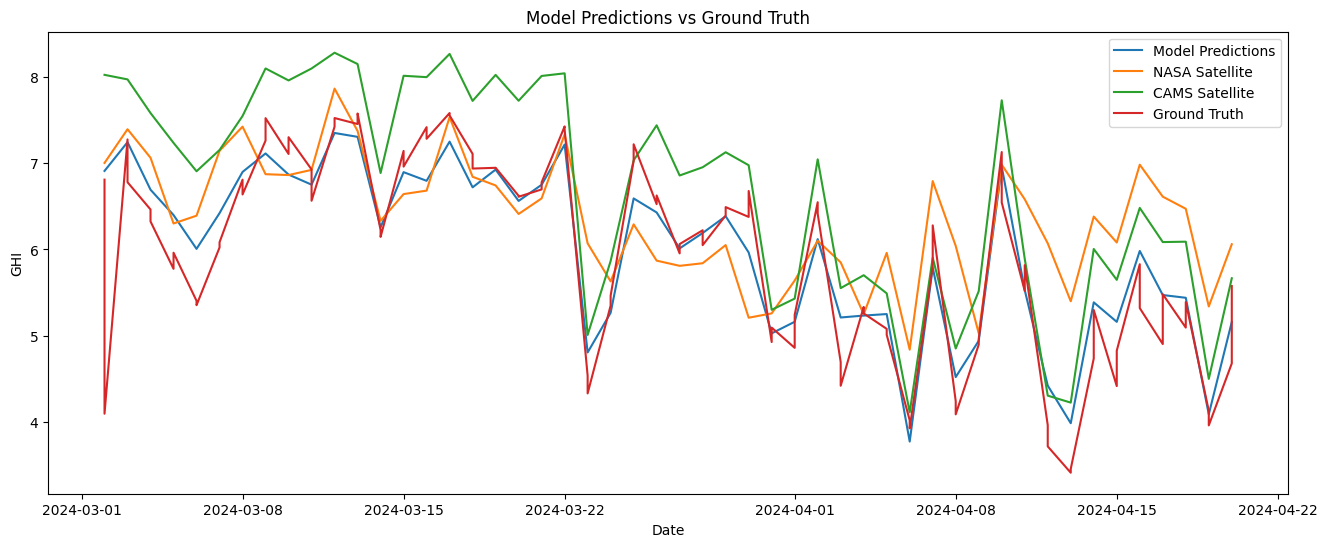

In [17]:
somalia = df_copy[df_copy['location'] == 'kenya_location11']
somalia_pred = xgboost_model.predict(somalia)
cutoff = 100

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(somalia_pred.index[:cutoff], somalia_pred.iloc[:cutoff], label='Model Predictions')
ax.plot(somalia.index[:cutoff], somalia['ghi_nasa'].iloc[:cutoff], label='NASA Satellite')
ax.plot(somalia.index[:cutoff], somalia['ghi_cams'].iloc[:cutoff], label='CAMS Satellite')
ax.plot(somalia.index[:cutoff], somalia['ghi'].iloc[:cutoff], label='Ground Truth')
ax.set_xlabel('Date')
ax.set_ylabel('GHI')
ax.set_title('Model Predictions vs Ground Truth')
ax.legend()
plt.show()

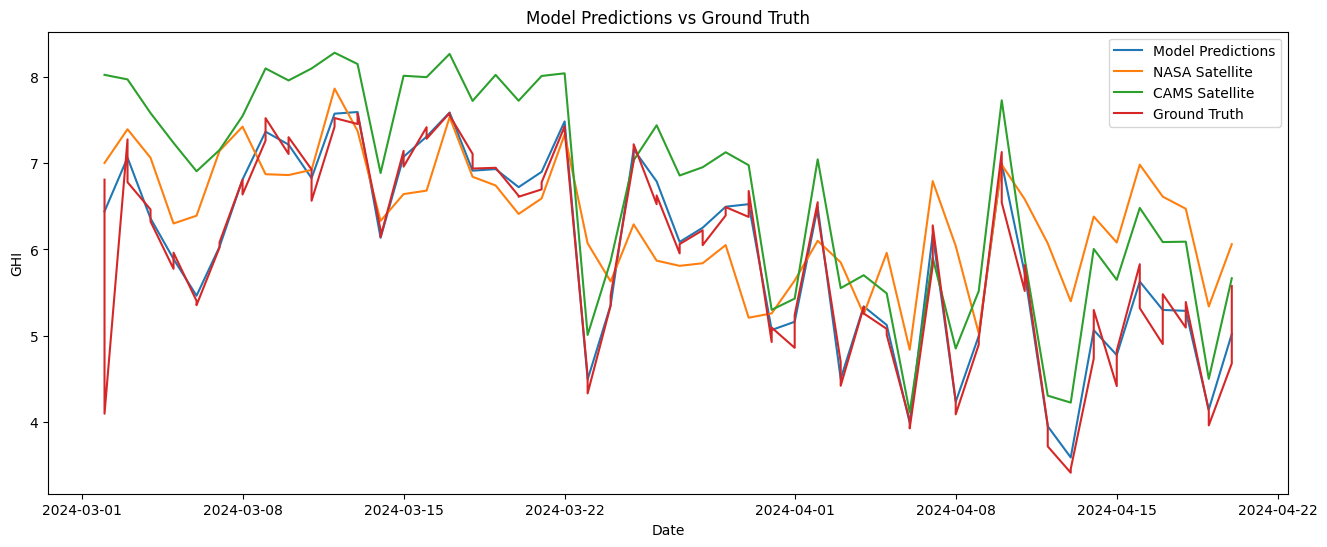

In [18]:
#@title rf pre
somalia = df_copy[df_copy['location'] == 'kenya_location11']
somalia_pred = ml_model.predict(somalia)
cutoff = 100

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(somalia_pred.index[:cutoff], somalia_pred.iloc[:cutoff], label='Model Predictions')
ax.plot(somalia.index[:cutoff], somalia['ghi_nasa'].iloc[:cutoff], label='NASA Satellite')
ax.plot(somalia.index[:cutoff], somalia['ghi_cams'].iloc[:cutoff], label='CAMS Satellite')
ax.plot(somalia.index[:cutoff], somalia['ghi'].iloc[:cutoff], label='Ground Truth')
ax.set_xlabel('Date')
ax.set_ylabel('GHI')
ax.set_title('Model Predictions vs Ground Truth')
ax.legend()
plt.show()

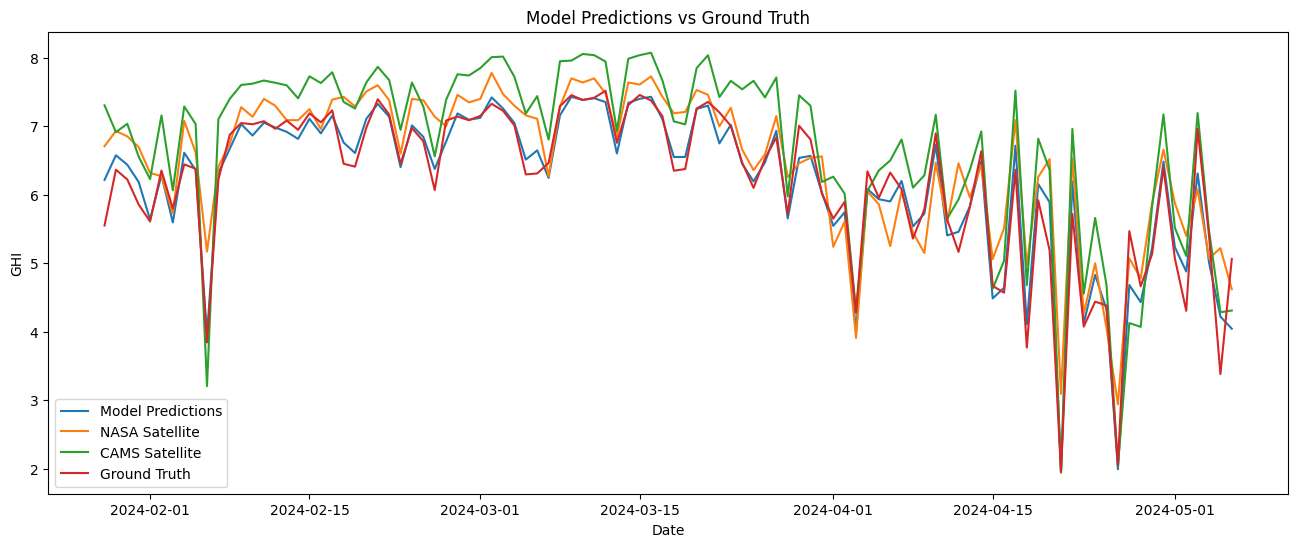

In [19]:
#@title rf pre
somalia = df_copy[df_copy['location'] == 'somalia_location1']
somalia_pred = ml_model.predict(somalia)
cutoff = 100

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(somalia_pred.index[:cutoff], somalia_pred.iloc[:cutoff], label='Model Predictions')
ax.plot(somalia.index[:cutoff], somalia['ghi_nasa'].iloc[:cutoff], label='NASA Satellite')
ax.plot(somalia.index[:cutoff], somalia['ghi_cams'].iloc[:cutoff], label='CAMS Satellite')
ax.plot(somalia.index[:cutoff], somalia['ghi'].iloc[:cutoff], label='Ground Truth')
ax.set_xlabel('Date')
ax.set_ylabel('GHI')
ax.set_title('Model Predictions vs Ground Truth')
ax.legend()
plt.show()

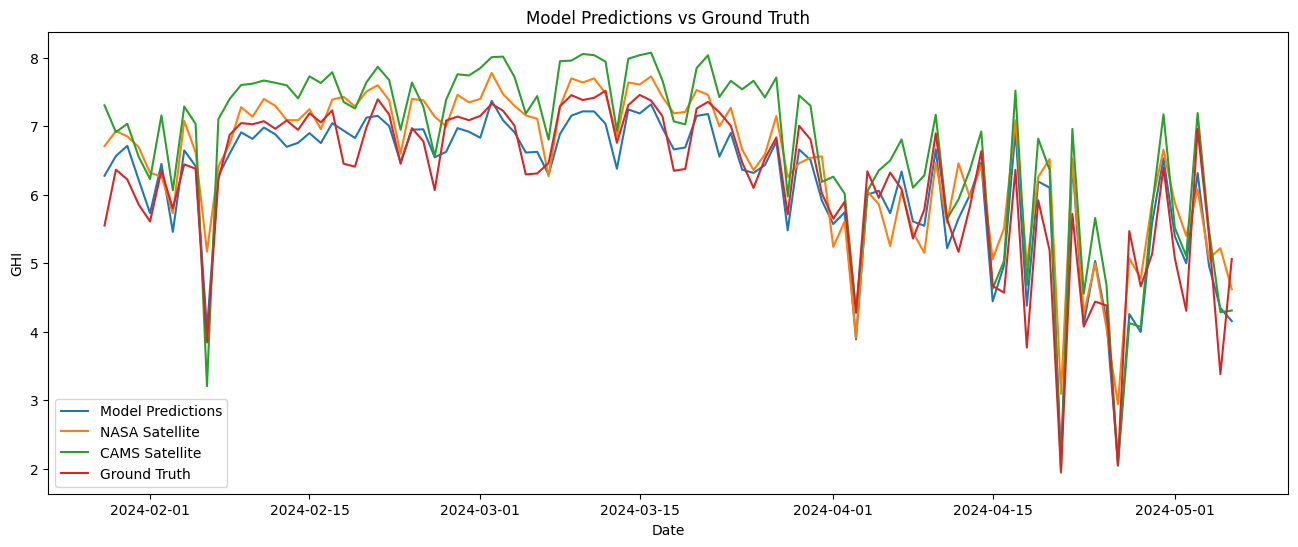

In [20]:
#@title rf pre
somalia = df_copy[df_copy['location'] == 'somalia_location1']
somalia_pred = xgboost_model.predict(somalia)
cutoff = 100

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(somalia_pred.index[:cutoff], somalia_pred.iloc[:cutoff], label='Model Predictions')
ax.plot(somalia.index[:cutoff], somalia['ghi_nasa'].iloc[:cutoff], label='NASA Satellite')
ax.plot(somalia.index[:cutoff], somalia['ghi_cams'].iloc[:cutoff], label='CAMS Satellite')
ax.plot(somalia.index[:cutoff], somalia['ghi'].iloc[:cutoff], label='Ground Truth')
ax.set_xlabel('Date')
ax.set_ylabel('GHI')
ax.set_title('Model Predictions vs Ground Truth')
ax.legend()
plt.show()